# AI Digital Evidence Intelligence Platform
## VAE V5 — Advanced Forensic Reconstruction Analysis

### Image Forensics Module using CASIA v2.0

This notebook develops and evaluates an advanced Variational Autoencoder (VAE) for digital image evidence analysis.

The objective is to investigate whether reconstruction behavior can provide useful supporting evidence for distinguishing authentic images from manipulated images.

The VAE is evaluated in two stages:

1. **Reconstruction stage** — improve image reconstruction quality.
2. **Forensic stage** — train the VAE using authentic images only and investigate whether tampered images produce different reconstruction behavior.

The VAE is treated as a **forensic anomaly-analysis component**, not as a standalone legally validated tampering detector.

In [1]:
# Install required libraries
!pip -q install torchmetrics torch-fidelity scikit-image

# Core libraries
import os
import json
import math
import random
import time
from pathlib import Path

# Numerical / data
import numpy as np
import pandas as pd

# Images
from PIL import Image
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Evaluation
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity as ssim

# Progress bar
from tqdm.auto import tqdm

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.6 MB/s eta 0:00:00
PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


# CELL 2 — Project & CASIA Dataset Setup

This section initializes the project workspace and defines the directory structure used throughout the experiment.

The project separates:

- Raw datasets
- Processed data
- Train/validation/test split manifests
- Model checkpoints
- Training histories
- Results and visualizations

A fixed random seed is used wherever applicable to improve reproducibility.

In [2]:

from pathlib import Path
import subprocess
import sys

# Project location
PROJECT_ROOT = Path("/content/AI-Digital-Evidence-Intelligence-Platform")

# Create required folders
(PROJECT_ROOT / "data").mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "checkpoints").mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "results").mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "outputs").mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Project folder ready:", PROJECT_ROOT.exists())

# Install Kaggle API if needed
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "kaggle"],
    check=True
)

print("Kaggle API ready.")

Project root: /content/AI-Digital-Evidence-Intelligence-Platform
Project folder ready: True
Kaggle API ready.


# CELL 3 — Download CASIA v2.0 Dataset

The experiment uses the **CASIA v2.0 Image Tampering Detection Dataset**.

CASIA v2.0 contains authentic images and manipulated images and provides separate ground-truth masks for tampered images.

The ground-truth masks are **not used as model inputs**. They are kept separate so that the reconstruction models do not receive direct information about the manipulated regions.

In [3]:

from google.colab import files
import os
import shutil
from pathlib import Path

# Kaggle credentials
KAGGLE_DIR = Path("/root/.kaggle")
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)

kaggle_json = Path("/content/kaggle.json")

if not kaggle_json.exists():
    print("Please upload your kaggle.json file.")
    uploaded = files.upload()

    if "kaggle.json" not in uploaded:
        raise FileNotFoundError("kaggle.json was not uploaded.")

shutil.copy(kaggle_json, KAGGLE_DIR / "kaggle.json")
os.chmod(KAGGLE_DIR / "kaggle.json", 0o600)

print("Kaggle credentials configured.")

# Dataset location
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "CASIA2"
DATASET_DIR.mkdir(parents=True, exist_ok=True)

# Download dataset
!kaggle datasets download -d divg07/casia-20-image-tampering-detection-dataset \
    -p "{PROJECT_ROOT / 'data' / 'raw'}"

print("CASIA dataset download completed.")

Please upload your kaggle.json file.


Saving kaggle.json to kaggle.json
Kaggle credentials configured.
Dataset URL: https://www.kaggle.com/datasets/divg07/casia-20-image-tampering-detection-dataset
License(s): unknown
100% 2.56G/2.56G [02:18<00:00, 19.9MB/s]

CASIA dataset download completed.


# CELL 4 — Extract and Inspect CASIA

The downloaded dataset archive is extracted into the project data directory.

After extraction, the top-level directory is inspected to verify that the dataset has been downloaded and extracted correctly before model preparation begins.

In [4]:

import zipfile
from pathlib import Path

RAW_DIR = PROJECT_ROOT / "data" / "raw"

# Find downloaded CASIA ZIP
zip_files = list(RAW_DIR.glob("*.zip"))

if not zip_files:
    raise FileNotFoundError("CASIA ZIP file not found.")

CASIA_ZIP = zip_files[0]

print("ZIP file:", CASIA_ZIP.name)
print("ZIP size:", round(CASIA_ZIP.stat().st_size / (1024**3), 2), "GB")

# Extract dataset
EXTRACT_DIR = RAW_DIR / "CASIA2"

if not EXTRACT_DIR.exists() or not any(EXTRACT_DIR.iterdir()):
    print("\nExtracting CASIA dataset...")

    with zipfile.ZipFile(CASIA_ZIP, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("Extraction completed.")
else:
    print("\nDataset already extracted.")

# Inspect top-level structure
print("\nTop-level contents:")

for item in sorted(EXTRACT_DIR.iterdir()):
    if item.is_dir():
        print("📁", item.name)
    else:
        print("📄", item.name)

ZIP file: casia-20-image-tampering-detection-dataset.zip
ZIP size: 2.56 GB

Extracting CASIA dataset...
Extraction completed.

Top-level contents:
📁 CASIA2


# CELL 5 — Inspect CASIA2 Folder Structure

The CASIA dataset is organized into separate directories for authentic and tampered images.

Expected structure:

CASIA2/
├── Au/                    → Authentic images
├── Tp/                    → Tampered images
└── CASIA 2 Groundtruth/   → Ground-truth masks

Only images from `Au` and `Tp` are used as model inputs.

Ground-truth masks are excluded from model training and inference.

In [5]:


CASIA_ROOT = EXTRACT_DIR / "CASIA2"

print("CASIA root:", CASIA_ROOT)
print("\nFolders inside CASIA2:\n")

for item in sorted(CASIA_ROOT.iterdir()):
    if item.is_dir():
        print("📁", item.name)
    else:
        print("📄", item.name)

CASIA root: /content/AI-Digital-Evidence-Intelligence-Platform/data/raw/CASIA2/CASIA2

Folders inside CASIA2:

📁 Au
📁 CASIA 2 Groundtruth
📁 Tp


# CELL 6 — CASIA Image Inventory & Validation

Before training, the dataset is systematically inspected.

The validation process checks:

- Number of authentic images
- Number of tampered images
- Total model-input images
- Duplicate paths
- Image readability
- Supported image formats

This step helps prevent corrupted files, duplicate entries, and accidental inclusion of ground-truth masks.

Expected model-input inventory:

- Authentic: 7,491
- Tampered: 5,123
- Total: 12,614

Ground-truth masks are excluded from the model-input inventory.

In [6]:

from PIL import Image
from collections import Counter

AU_DIR = CASIA_ROOT / "Au"
TP_DIR = CASIA_ROOT / "Tp"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def collect_images(folder):
    return sorted([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

# Collect authentic and tampered images
authentic_images = collect_images(AU_DIR)
tampered_images = collect_images(TP_DIR)

print("CASIA IMAGE INVENTORY")
print("=" * 50)

print(f"Authentic images : {len(authentic_images):,}")
print(f"Tampered images  : {len(tampered_images):,}")
print(f"Total images     : {len(authentic_images) + len(tampered_images):,}")

# Check for duplicate paths
all_paths = authentic_images + tampered_images
print(f"\nUnique paths     : {len(set(map(str, all_paths))):,}")

# Validate image readability
print("\nChecking image readability...")

bad_authentic = []
bad_tampered = []

for path in tqdm(authentic_images, desc="Authentic"):
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception:
        bad_authentic.append(path)

for path in tqdm(tampered_images, desc="Tampered"):
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception:
        bad_tampered.append(path)

print("\nVALIDATION RESULT")
print("=" * 50)
print(f"Unreadable authentic : {len(bad_authentic)}")
print(f"Unreadable tampered  : {len(bad_tampered)}")

# Show a few sample paths
print("\nSample authentic images:")
for p in authentic_images[:5]:
    print(" ", p)

print("\nSample tampered images:")
for p in tampered_images[:5]:
    print(" ", p)

CASIA IMAGE INVENTORY
Authentic images : 7,491
Tampered images  : 5,123
Total images     : 12,614

Unique paths     : 12,614

Checking image readability...


Authentic:   0%|          | 0/7491 [00:00<?, ?it/s]

Tampered:   0%|          | 0/5123 [00:00<?, ?it/s]


VALIDATION RESULT
Unreadable authentic : 0
Unreadable tampered  : 0

Sample authentic images:
  /content/AI-Digital-Evidence-Intelligence-Platform/data/raw/CASIA2/CASIA2/Au/Au_ani_00001.jpg
  /content/AI-Digital-Evidence-Intelligence-Platform/data/raw/CASIA2/CASIA2/Au/Au_ani_00002.jpg
  /content/AI-Digital-Evidence-Intelligence-Platform/data/raw/CASIA2/CASIA2/Au/Au_ani_00003.jpg
  /content/AI-Digital-Evidence-Intelligence-Platform/data/raw/CASIA2/CASIA2/Au/Au_ani_00004.jpg
  /content/AI-Digital-Evidence-Intelligence-Platform/data/raw/CASIA2/CASIA2/Au/Au_ani_00005.jpg

Sample tampered images:
  /content/AI-Digital-Evidence-Intelligence-Platform/data/raw/CASIA2/CASIA2/Tp/Tp_D_CND_M_N_ani00018_sec00096_00138.tif
  /content/AI-Digital-Evidence-Intelligence-Platform/data/raw/CASIA2/CASIA2/Tp/Tp_D_CND_M_N_art00076_art00077_10289.tif
  /content/AI-Digital-Evidence-Intelligence-Platform/data/raw/CASIA2/CASIA2/Tp/Tp_D_CND_M_N_art00077_art00076_10290.tif
  /content/AI-Digital-Evidence-Intellige

# CELL 7 — Reproducible Train / Validation / Test Split

The dataset is divided into three independent subsets:

- Training set
- Validation set
- Test set

A stratified split is used so that authentic and tampered images remain proportionally represented across the subsets.

A fixed random seed is used to make the split reproducible.

The test set is kept separate from model development and is used only for final evaluation.

In [7]:


from sklearn.model_selection import train_test_split

# Create dataframe
data = []

for path in authentic_images:
    data.append({
        "image_path": str(path),
        "label": 0,
        "class_name": "authentic"
    })

for path in tampered_images:
    data.append({
        "image_path": str(path),
        "label": 1,
        "class_name": "tampered"
    })

df = pd.DataFrame(data)

# Shuffle once using fixed seed
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# ------------------------------------------------------------
# 70% Train / 30% Temporary
# ------------------------------------------------------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

# ------------------------------------------------------------
# 15% Validation / 15% Test
# ------------------------------------------------------------
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# Print split information
# ------------------------------------------------------------
print("DATASET SPLIT")
print("=" * 60)

print(f"Total      : {len(df):,}")
print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")

print("\nCLASS DISTRIBUTION")
print("=" * 60)

print("\nTrain:")
print(train_df["class_name"].value_counts())

print("\nValidation:")
print(val_df["class_name"].value_counts())

print("\nTest:")
print(test_df["class_name"].value_counts())

# ------------------------------------------------------------
# Save split manifests
# ------------------------------------------------------------

SPLIT_DIR = PROJECT_ROOT / "data" / "splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(SPLIT_DIR / "vae_train.csv", index=False)
val_df.to_csv(SPLIT_DIR / "vae_validation.csv", index=False)
test_df.to_csv(SPLIT_DIR / "vae_test.csv", index=False)

print("\nSplit files saved to:")
print(SPLIT_DIR)

DATASET SPLIT
Total      : 12,614
Train      : 8,829
Validation : 1,892
Test       : 1,893

CLASS DISTRIBUTION

Train:
class_name
authentic    5243
tampered     3586
Name: count, dtype: int64

Validation:
class_name
authentic    1124
tampered      768
Name: count, dtype: int64

Test:
class_name
authentic    1124
tampered      769
Name: count, dtype: int64

Split files saved to:
/content/AI-Digital-Evidence-Intelligence-Platform/data/splits


# CELL 8 — VAE Dataset & Preprocessing

All images are converted to RGB and resized to a common resolution of **128 × 128 pixels**.

The preprocessing pipeline uses:

- RGB conversion
- 128 × 128 resizing
- Tensor conversion
- Pixel range [0, 1]

No ImageNet normalization is applied because the VAE reconstructs the input image directly.

Authentic/tampered labels are retained as metadata for forensic evaluation. They are not used as reconstruction targets.

In [8]:

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

IMAGE_SIZE = 128
BATCH_SIZE = 32

# ------------------------------------------------------------
# Image transformation
# ------------------------------------------------------------

vae_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=transforms.InterpolationMode.BILINEAR
    ),
    transforms.ToTensor()
])

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class CASIAVAEDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        label = int(row["label"])

        # Open image safely
        image = Image.open(image_path).convert("RGB")

        # Apply preprocessing
        if self.transform:
            image = self.transform(image)

        return image, label, image_path


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_dataset = CASIAVAEDataset(
    train_df,
    transform=vae_transform
)

val_dataset = CASIAVAEDataset(
    val_df,
    transform=vae_transform
)

test_dataset = CASIAVAEDataset(
    test_df,
    transform=vae_transform
)

# ------------------------------------------------------------
# Create DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# ------------------------------------------------------------
# Verify one batch
# ------------------------------------------------------------

images, labels, paths = next(iter(train_loader))

print("VAE DATASET READY")
print("=" * 50)
print("Image batch shape :", images.shape)
print("Label shape       :", labels.shape)
print("Pixel minimum     :", images.min().item())
print("Pixel maximum     :", images.max().item())
print("Train batches     :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches      :", len(test_loader))

VAE DATASET READY
Image batch shape : torch.Size([32, 3, 128, 128])
Label shape       : torch.Size([32])
Pixel minimum     : 0.0
Pixel maximum     : 1.0
Train batches     : 276
Validation batches: 60
Test batches      : 60


# CELL 9 — Improved VAE V3 Architecture

VAE V3 is used as an improved baseline before introducing the more advanced V5 architecture.

The encoder progressively reduces the spatial resolution:

128 × 128
→ 64 × 64
→ 32 × 32
→ 16 × 16
→ 8 × 8

The encoder produces two latent variables:

- Mean (`mu`)
- Log variance (`logvar`)

The decoder reconstructs the image from the sampled latent representation.

V3 uses a **128-dimensional latent space**.

The output uses a Sigmoid activation so reconstructed pixels remain in the [0, 1] range.

In [9]:


class ImprovedVAE(nn.Module):

    def __init__(self, latent_dim=128):
        super().__init__()

        self.latent_dim = latent_dim

        # ----------------------------------------------------
        # Encoder
        # 128x128 -> 64x64 -> 32x32 -> 16x16 -> 8x8
        # ----------------------------------------------------

        self.encoder = nn.Sequential(

            # 3 -> 32
            nn.Conv2d(
                3, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 -> 64
            nn.Conv2d(
                32, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 -> 128
            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 -> 256
            nn.Conv2d(
                128, 256,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # 256 x 8 x 8 = 16384
        self.flatten_dim = 256 * 8 * 8

        # Latent distribution
        self.fc_mu = nn.Linear(
            self.flatten_dim,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            self.flatten_dim,
            latent_dim
        )

        # ----------------------------------------------------
        # Decoder input
        # ----------------------------------------------------

        self.decoder_input = nn.Linear(
            latent_dim,
            self.flatten_dim
        )

        # ----------------------------------------------------
        # Decoder
        # 8x8 -> 16x16 -> 32x32 -> 64x64 -> 128x128
        # ----------------------------------------------------

        self.decoder = nn.Sequential(

            # 256 -> 128
            nn.ConvTranspose2d(
                256, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # 128 -> 64
            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 64 -> 32
            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # 32 -> 3
            nn.ConvTranspose2d(
                32, 3,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            # Output in [0,1]
            nn.Sigmoid()
        )

    # --------------------------------------------------------
    # Encode
    # --------------------------------------------------------

    def encode(self, x):

        features = self.encoder(x)

        features = torch.flatten(
            features,
            start_dim=1
        )

        mu = self.fc_mu(features)
        logvar = self.fc_logvar(features)

        return mu, logvar

    # --------------------------------------------------------
    # Reparameterization
    # --------------------------------------------------------

    def reparameterize(self, mu, logvar):

        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(std)

        return mu + eps * std

    # --------------------------------------------------------
    # Decode
    # --------------------------------------------------------

    def decode(self, z):

        x = self.decoder_input(z)

        x = x.view(
            -1,
            256,
            8,
            8
        )

        return self.decoder(x)

    # --------------------------------------------------------
    # Forward
    # --------------------------------------------------------

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

LATENT_DIM = 128

vae = ImprovedVAE(
    latent_dim=LATENT_DIM
).to(DEVICE)

# Parameter count
total_params = sum(
    p.numel()
    for p in vae.parameters()
)

trainable_params = sum(
    p.numel()
    for p in vae.parameters()
    if p.requires_grad
)

print("IMPROVED VAE")
print("=" * 50)
print("Latent dimension :", LATENT_DIM)
print("Total parameters :", f"{total_params:,}")
print("Trainable params :", f"{trainable_params:,}")
print("Device           :", DEVICE)

# ------------------------------------------------------------
# Architecture verification
# ------------------------------------------------------------

dummy = torch.randn(
    2, 3, IMAGE_SIZE, IMAGE_SIZE
).to(DEVICE)

with torch.no_grad():
    reconstruction, mu, logvar = vae(dummy)

print("\nSHAPE CHECK")
print("=" * 50)
print("Input            :", dummy.shape)
print("Reconstruction   :", reconstruction.shape)
print("Mu               :", mu.shape)
print("Logvar           :", logvar.shape)

assert reconstruction.shape == dummy.shape
assert mu.shape == (2, LATENT_DIM)
assert logvar.shape == (2, LATENT_DIM)

print("\n✓ Architecture verification passed.")

IMPROVED VAE
Latent dimension : 128
Total parameters : 7,689,539
Trainable params : 7,689,539
Device           : cuda

SHAPE CHECK
Input            : torch.Size([2, 3, 128, 128])
Reconstruction   : torch.Size([2, 3, 128, 128])
Mu               : torch.Size([2, 128])
Logvar           : torch.Size([2, 128])

✓ Architecture verification passed.


# CELL 10 — Improved VAE Loss

The VAE objective combines reconstruction quality with latent-space regularization.

The reconstruction component contains:

- Mean Squared Error (MSE)
- L1 reconstruction loss

The KL-divergence term regularizes the latent distribution toward a standard normal distribution.

Overall:

Total Loss =
Reconstruction Loss + β × KL Divergence

A small β value is used because reconstruction quality is particularly important for this image-forensics experiment.

In [10]:


def vae_loss(
    reconstruction,
    target,
    mu,
    logvar,
    beta=0.0005,
    l1_weight=0.5
):
    """
    Improved VAE objective.

    Reconstruction loss:
        L1 + MSE

    KL loss:
        Regularizes the latent distribution.

    Total:
        reconstruction_loss + beta * KL
    """

    # --------------------------------------------------------
    # Pixel reconstruction losses
    # --------------------------------------------------------

    mse_loss = F.mse_loss(
        reconstruction,
        target,
        reduction="mean"
    )

    l1_loss = F.l1_loss(
        reconstruction,
        target,
        reduction="mean"
    )

    # Combined reconstruction objective
    reconstruction_loss = (
        (1.0 - l1_weight) * mse_loss
        + l1_weight * l1_loss
    )

    # --------------------------------------------------------
    # KL divergence
    # --------------------------------------------------------

    kl_loss = -0.5 * torch.mean(
        torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp(),
            dim=1
        )
    )

    # --------------------------------------------------------
    # Total loss
    # --------------------------------------------------------

    total_loss = (
        reconstruction_loss
        + beta * kl_loss
    )

    return {
        "total": total_loss,
        "reconstruction": reconstruction_loss,
        "mse": mse_loss,
        "l1": l1_loss,
        "kl": kl_loss
    }


# ------------------------------------------------------------
# Loss configuration
# ------------------------------------------------------------

BETA = 0.0005
L1_WEIGHT = 0.5

print("IMPROVED VAE LOSS")
print("=" * 50)
print("MSE contribution :", 1.0 - L1_WEIGHT)
print("L1 contribution  :", L1_WEIGHT)
print("KL beta          :", BETA)
print("\n✓ Loss function ready.")

IMPROVED VAE LOSS
MSE contribution : 0.5
L1 contribution  : 0.5
KL beta          : 0.0005

✓ Loss function ready.


# CELL 11 — VAE V3 Training Configuration

V3 is trained using:

- AdamW optimizer
- Learning rate: 1 × 10⁻⁴
- Weight decay: 1 × 10⁻⁵
- Batch size: 32
- KL warm-up
- Gradient clipping
- Learning-rate scheduling

The model checkpoint is selected using validation reconstruction MSE.

Validation MSE is used for checkpoint selection because the primary purpose of this experiment is image reconstruction quality.

In [12]:
# ============================================================
# CELL 11 — VAE TRAINING CONFIGURATION
# ============================================================

# Training settings
EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

# KL warm-up
KL_WARMUP_EPOCHS = 10
BETA_START = 0.0001
BETA_END = 0.0005

# Early stopping
PATIENCE = 7

# Gradient clipping
GRAD_CLIP = 1.0

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    vae.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# Learning-rate scheduler
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("VAE TRAINING CONFIGURATION")
print("=" * 55)

print(f"Epochs              : {EPOCHS}")
print(f"Learning rate       : {LEARNING_RATE}")
print(f"Weight decay        : {WEIGHT_DECAY}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Latent dimension    : {LATENT_DIM}")

print("\nKL warm-up")
print(f"Warm-up epochs      : {KL_WARMUP_EPOCHS}")
print(f"Beta start          : {BETA_START}")
print(f"Beta end            : {BETA_END}")

print("\nTraining control")
print(f"Early-stop patience : {PATIENCE}")
print(f"Gradient clipping   : {GRAD_CLIP}")

print("\n✓ Optimizer and scheduler ready.")

VAE TRAINING CONFIGURATION
Epochs              : 50
Learning rate       : 0.0001
Weight decay        : 1e-05
Batch size          : 32
Latent dimension    : 128

KL warm-up
Warm-up epochs      : 10
Beta start          : 0.0001
Beta end            : 0.0005

Training control
Early-stop patience : 7
Gradient clipping   : 1.0

✓ Optimizer and scheduler ready.


# CELL 12 — Corrected VAE V3 Training

A fresh VAE V3 model is initialized before training.

KL warm-up gradually increases the KL contribution during training rather than applying the full KL penalty immediately.

The experiment records:

- Training loss
- Validation loss
- MSE
- L1 loss
- Reconstruction loss
- KL divergence
- PSNR
- Learning rate
- β value

The best model is preserved according to validation MSE.

In [13]:


vae = ImprovedVAE(
    latent_dim=LATENT_DIM
).to(DEVICE)

# Fresh optimizer
optimizer = torch.optim.AdamW(
    vae.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Fresh scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

EPOCHS_V3 = 50

KL_WARMUP_EPOCHS_V3 = 15

BETA_START_V3 = 0.0001
BETA_END_V3 = 0.0005

EARLY_STOP_PATIENCE = 8

GRAD_CLIP_V3 = 1.0

BEST_VAE_V3_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "best_vae_v3_corrected.pth"
)

# ------------------------------------------------------------
# History
# ------------------------------------------------------------

history_v3 = {
    "train_total": [],
    "val_total": [],

    "train_mse": [],
    "val_mse": [],

    "train_l1": [],
    "val_l1": [],

    "train_recon": [],
    "val_recon": [],

    "train_kl": [],
    "val_kl": [],

    "val_psnr": [],

    "beta": [],
    "lr": []
}

# ------------------------------------------------------------
# Best model tracking
# IMPORTANT:
# We select the best model using VALIDATION MSE.
# ------------------------------------------------------------

best_val_mse = float("inf")
best_epoch = 0
epochs_without_improvement = 0

print("STARTING CORRECTED VAE V3 TRAINING")
print("=" * 75)

for epoch in range(1, EPOCHS_V3 + 1):

    # --------------------------------------------------------
    # KL warm-up
    # --------------------------------------------------------

    if epoch <= KL_WARMUP_EPOCHS_V3:

        beta = (
            BETA_START_V3
            + (BETA_END_V3 - BETA_START_V3)
            * (epoch - 1)
            / max(KL_WARMUP_EPOCHS_V3 - 1, 1)
        )

    else:

        beta = BETA_END_V3

    # ========================================================
    # TRAIN
    # ========================================================

    vae.train()

    train_total = 0.0
    train_mse = 0.0
    train_l1 = 0.0
    train_recon = 0.0
    train_kl = 0.0

    for images, _, _ in tqdm(
        train_loader,
        desc=f"Epoch {epoch:02d}/{EPOCHS_V3}",
        leave=False
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        # Forward pass
        reconstruction, mu, logvar = vae(images)

        # Loss
        losses = vae_loss(
            reconstruction,
            images,
            mu,
            logvar,
            beta=beta,
            l1_weight=L1_WEIGHT
        )

        # Backpropagation
        losses["total"].backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            vae.parameters(),
            GRAD_CLIP_V3
        )

        optimizer.step()

        batch_size = images.size(0)

        train_total += (
            losses["total"].item()
            * batch_size
        )

        train_mse += (
            losses["mse"].item()
            * batch_size
        )

        train_l1 += (
            losses["l1"].item()
            * batch_size
        )

        train_recon += (
            losses["reconstruction"].item()
            * batch_size
        )

        train_kl += (
            losses["kl"].item()
            * batch_size
        )

    # Average
    train_total /= len(train_dataset)
    train_mse /= len(train_dataset)
    train_l1 /= len(train_dataset)
    train_recon /= len(train_dataset)
    train_kl /= len(train_dataset)

    # ========================================================
    # VALIDATION
    # ========================================================

    vae.eval()

    val_total = 0.0
    val_mse = 0.0
    val_l1 = 0.0
    val_recon = 0.0
    val_kl = 0.0

    with torch.no_grad():

        for images, _, _ in val_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            # ------------------------------------------------
            # IMPORTANT:
            # Use MU instead of random Z for deterministic
            # reconstruction evaluation.
            # ------------------------------------------------

            mu, logvar = vae.encode(images)

            reconstruction = vae.decode(mu)

            # Calculate losses
            mse = F.mse_loss(
                reconstruction,
                images,
                reduction="mean"
            )

            l1 = F.l1_loss(
                reconstruction,
                images,
                reduction="mean"
            )

            recon_loss = (
                (1.0 - L1_WEIGHT) * mse
                + L1_WEIGHT * l1
            )

            kl = -0.5 * torch.mean(
                torch.sum(
                    1
                    + logvar
                    - mu.pow(2)
                    - logvar.exp(),
                    dim=1
                )
            )

            total = (
                recon_loss
                + beta * kl
            )

            batch_size = images.size(0)

            val_total += total.item() * batch_size
            val_mse += mse.item() * batch_size
            val_l1 += l1.item() * batch_size
            val_recon += recon_loss.item() * batch_size
            val_kl += kl.item() * batch_size

    # Average
    val_total /= len(val_dataset)
    val_mse /= len(val_dataset)
    val_l1 /= len(val_dataset)
    val_recon /= len(val_dataset)
    val_kl /= len(val_dataset)

    # --------------------------------------------------------
    # PSNR from validation MSE
    # --------------------------------------------------------

    val_psnr = -10.0 * math.log10(
        max(val_mse, 1e-12)
    )

    # --------------------------------------------------------
    # Scheduler
    #
    # IMPORTANT:
    # Scheduler also follows reconstruction MSE.
    # --------------------------------------------------------

    scheduler.step(val_mse)

    current_lr = optimizer.param_groups[0]["lr"]

    # ========================================================
    # Store history
    # ========================================================

    history_v3["train_total"].append(train_total)
    history_v3["val_total"].append(val_total)

    history_v3["train_mse"].append(train_mse)
    history_v3["val_mse"].append(val_mse)

    history_v3["train_l1"].append(train_l1)
    history_v3["val_l1"].append(val_l1)

    history_v3["train_recon"].append(train_recon)
    history_v3["val_recon"].append(val_recon)

    history_v3["train_kl"].append(train_kl)
    history_v3["val_kl"].append(val_kl)

    history_v3["val_psnr"].append(val_psnr)

    history_v3["beta"].append(beta)
    history_v3["lr"].append(current_lr)

    # ========================================================
    # BEST CHECKPOINT
    #
    # Lower validation MSE = better reconstruction.
    # ========================================================

    improved = val_mse < best_val_mse

    if improved:

        best_val_mse = val_mse
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    vae.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "val_mse":
                    val_mse,

                "val_psnr":
                    val_psnr,

                "val_reconstruction_loss":
                    val_recon,

                "val_kl":
                    val_kl,

                "latent_dim":
                    LATENT_DIM,

                "image_size":
                    IMAGE_SIZE,

                "l1_weight":
                    L1_WEIGHT,

                "beta":
                    beta
            },
            BEST_VAE_V3_PATH
        )

    else:

        epochs_without_improvement += 1

    # ========================================================
    # EPOCH REPORT
    # ========================================================

    print(
        f"Epoch {epoch:02d} | "
        f"Train MSE: {train_mse:.5f} | "
        f"Val MSE: {val_mse:.5f} | "
        f"PSNR: {val_psnr:.2f} dB | "
        f"Val KL: {val_kl:.4f} | "
        f"β: {beta:.5f} | "
        f"LR: {current_lr:.2e}"
        + ("  ★ BEST" if improved else "")
    )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:

        print(
            f"\nEarly stopping after {epoch} epochs."
        )

        break


# ============================================================
# TRAINING COMPLETE
# ============================================================

print("\n" + "=" * 75)
print("CORRECTED VAE V3 TRAINING COMPLETE")
print("=" * 75)

print(f"Best epoch       : {best_epoch}")
print(f"Best validation MSE : {best_val_mse:.6f}")
print(
    f"Best validation PSNR: "
    f"{-10.0 * math.log10(max(best_val_mse, 1e-12)):.2f} dB"
)
print(f"Checkpoint       : {BEST_VAE_V3_PATH}")

STARTING CORRECTED VAE V3 TRAINING


Epoch 01/50:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 01 | Train MSE: 0.04177 | Val MSE: 0.02717 | PSNR: 15.66 dB | Val KL: 79.9775 | β: 0.00010 | LR: 1.00e-04  ★ BEST


Epoch 02/50:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 02 | Train MSE: 0.02873 | Val MSE: 0.02545 | PSNR: 15.94 dB | Val KL: 69.3758 | β: 0.00013 | LR: 1.00e-04  ★ BEST


...

Epoch 11 | Train MSE: 0.02434 | Val MSE: 0.02084 | PSNR: 16.81 dB | Val KL: 36.1658 | β: 0.00039 | LR: 5.00e-05


Epoch 12/50:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 12 | Train MSE: 0.02472 | Val MSE: 0.02130 | PSNR: 16.72 dB | Val KL: 34.1830 | β: 0.00041 | LR: 5.00e-05


Epoch 13/50:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 13 | Train MSE: 0.02496 | Val MSE: 0.02145 | PSNR: 16.69 dB | Val KL: 31.8788 | β: 0.00044 | LR: 2.50e-05

Early stopping after 13 epochs.

CORRECTED VAE V3 TRAINING COMPLETE
Best epoch       : 5
Best validation MSE : 0.019842
Best validation PSNR: 17.02 dB
Checkpoint       : /content/AI-Digital-Evidence-Intelligence-Platform/checkpoints/best_vae_v3_corrected.pth


# CELL 13 — VAE V3 Reconstruction Visualization

The trained V3 model is evaluated visually by comparing original images with their reconstructed versions.

The purpose is to determine whether the improved architecture produces visually meaningful reconstructions and whether important structures are preserved.

This qualitative evaluation complements the numerical MSE and PSNR measurements.

# VAE V5 — Advanced Reconstruction Experiment

VAE V5 is introduced to improve reconstruction quality beyond the V3 baseline.

The architecture combines:

- Residual learning
- Group Normalization
- SiLU activation
- A 256-dimensional latent representation
- Multi-level encoder features
- Decoder skip connections
- Bilinear upsampling

The objective is to produce a more capable reconstruction model while retaining a latent representation suitable for forensic experimentation.

V5 is evaluated first as a reconstruction model and then as an authentic-only forensic model.

# VAE V5 — Improved Architecture

The V5 encoder extracts increasingly abstract image features while reducing spatial resolution.

Residual blocks help preserve useful feature information through deeper layers.

Group Normalization provides stable feature normalization, while SiLU provides a smooth nonlinear activation.

The decoder uses bilinear interpolation followed by convolution instead of relying entirely on transposed convolutions.

Skip connections transfer intermediate spatial information from the encoder to corresponding decoder stages.

The final architecture uses a **256-dimensional latent space** and reconstructs 128 × 128 RGB images.

In [20]:
# ============================================================
# VAE V5 — IMPROVED ARCHITECTURE
# Residual Blocks + GroupNorm + SiLU + Skip Connections
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# RESIDUAL BLOCK
# ============================================================

class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=channels
            ),

            nn.SiLU(),

            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=channels
            )
        )

        self.activation = nn.SiLU()


    def forward(self, x):

        residual = x

        x = self.block(x)

        x = x + residual

        return self.activation(x)


# ============================================================
# VAE V5
# ============================================================

class VAEV5(nn.Module):

    def __init__(self, latent_dim=256):

        super().__init__()

        self.latent_dim = latent_dim


        # ====================================================
        # ENCODER
        # ====================================================

        self.e1 = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=32
            ),

            nn.SiLU(),

            ResidualBlock(32)
        )


        self.e2 = nn.Sequential(

            nn.Conv2d(
                32,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=64
            ),

            nn.SiLU(),

            ResidualBlock(64)
        )


        self.e3 = nn.Sequential(

            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=128
            ),

            nn.SiLU(),

            ResidualBlock(128)
        )


        self.e4 = nn.Sequential(

            nn.Conv2d(
                128,
                256,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=256
            ),

            nn.SiLU(),

            ResidualBlock(256)
        )


        # ====================================================
        # LATENT SPACE
        # 256 × 8 × 8 = 16384
        # ====================================================

        self.feature_dim = 256 * 8 * 8


        self.fc_mu = nn.Linear(
            self.feature_dim,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            self.feature_dim,
            latent_dim
        )


        self.fc_decode = nn.Linear(
            latent_dim,
            self.feature_dim
        )


        # ====================================================
        # DECODER
        # ====================================================

        self.d4 = nn.Sequential(

            nn.Conv2d(
                256,
                256,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=256
            ),

            nn.SiLU(),

            ResidualBlock(256)
        )


        # After concatenating e3:
        # 256 + 128 = 384 channels

        self.d3 = nn.Sequential(

            nn.Conv2d(
                384,
                128,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=128
            ),

            nn.SiLU(),

            ResidualBlock(128)
        )


        # After concatenating e2:
        # 128 + 64 = 192 channels

        self.d2 = nn.Sequential(

            nn.Conv2d(
                192,
                64,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=64
            ),

            nn.SiLU(),

            ResidualBlock(64)
        )


        # After concatenating e1:
        # 64 + 32 = 96 channels

        self.d1 = nn.Sequential(

            nn.Conv2d(
                96,
                32,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=32
            ),

            nn.SiLU(),

            ResidualBlock(32)
        )


        # Final reconstruction layer

        self.final = nn.Conv2d(
            32,
            3,
            kernel_size=3,
            padding=1
        )


    # ========================================================
    # REPARAMETERIZATION
    # ========================================================

    def reparameterize(self, mu, logvar):

        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(std)

        return mu + eps * std


    # ========================================================
    # ENCODER
    # ========================================================

    def encode(self, x):

        e1 = self.e1(x)

        e2 = self.e2(e1)

        e3 = self.e3(e2)

        e4 = self.e4(e3)


        flattened = e4.view(
            e4.size(0),
            -1
        )


        mu = self.fc_mu(
            flattened
        )

        logvar = self.fc_logvar(
            flattened
        )


        return (
            mu,
            logvar,
            e1,
            e2,
            e3,
            e4
        )


    # ========================================================
    # DECODER
    # ========================================================

    def decode(
        self,
        z,
        e1,
        e2,
        e3,
        e4
    ):

        x = self.fc_decode(z)

        x = x.view(
            -1,
            256,
            8,
            8
        )


        # ----------------------------------------------------
        # 8 × 8 → 16 × 16
        # ----------------------------------------------------

        x = self.d4(x)

        x = F.interpolate(
            x,
            size=e3.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [x, e3],
            dim=1
        )

        x = self.d3(x)


        # ----------------------------------------------------
        # 16 × 16 → 32 × 32
        # ----------------------------------------------------

        x = F.interpolate(
            x,
            size=e2.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [x, e2],
            dim=1
        )

        x = self.d2(x)


        # ----------------------------------------------------
        # 32 × 32 → 64 × 64
        # ----------------------------------------------------

        x = F.interpolate(
            x,
            size=e1.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [x, e1],
            dim=1
        )

        x = self.d1(x)


        # ----------------------------------------------------
        # 64 × 64 → 128 × 128
        # ----------------------------------------------------

        x = F.interpolate(
            x,
            scale_factor=2,
            mode="bilinear",
            align_corners=False
        )


        x = self.final(x)

        x = torch.sigmoid(x)

        return x


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, x):

        (
            mu,
            logvar,
            e1,
            e2,
            e3,
            e4
        ) = self.encode(x)


        z = self.reparameterize(
            mu,
            logvar
        )


        reconstruction = self.decode(
            z,
            e1,
            e2,
            e3,
            e4
        )


        return (
            reconstruction,
            mu,
            logvar
        )


# ============================================================
# CREATE V5 MODEL
# ============================================================

LATENT_DIM_V5 = 256

vae_v5 = VAEV5(
    latent_dim=LATENT_DIM_V5
).to(DEVICE)


# ============================================================
# MODEL INFORMATION
# ============================================================

total_params_v5 = sum(
    p.numel()
    for p in vae_v5.parameters()
)


print("=" * 75)
print("VAE V5 MODEL READY")
print("=" * 75)

print(
    "Latent dimension :",
    LATENT_DIM_V5
)

print(
    "Total parameters :",
    f"{total_params_v5:,}"
)


# ============================================================
# SHAPE CHECK
# ============================================================

with torch.no_grad():

    dummy = torch.randn(
        2,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE
    ).to(DEVICE)


    reconstruction, mu, logvar = (
        vae_v5(dummy)
    )


print()
print("Input shape      :", dummy.shape)
print("Output shape     :", reconstruction.shape)
print("Mu shape         :", mu.shape)
print("Logvar shape     :", logvar.shape)


# ============================================================
# FINAL CHECK
# ============================================================

assert reconstruction.shape == dummy.shape

assert mu.shape == (
    2,
    LATENT_DIM_V5
)

assert logvar.shape == (
    2,
    LATENT_DIM_V5
)


print()
print("=" * 75)
print("✓ VAE V5 initialized successfully")
print("✓ Architecture shape check passed")
print("=" * 75)

VAE V5 MODEL READY
Latent dimension : 256
Total parameters : 17,599,971

Input shape      : torch.Size([2, 3, 128, 128])
Output shape     : torch.Size([2, 3, 128, 128])
Mu shape         : torch.Size([2, 256])
Logvar shape     : torch.Size([2, 256])

✓ VAE V5 initialized successfully
✓ Architecture shape check passed


# VAE V5 — Loss Function

V5 uses a hybrid reconstruction objective consisting of:

- MSE loss
- L1 loss
- KL divergence

The reconstruction loss is:

Reconstruction Loss =
0.5 × MSE + 0.5 × L1

The total VAE loss is:

Total Loss =
Reconstruction Loss + β × KL

A KL warm-up strategy is used so that the latent regularization increases gradually during training.

In [23]:
# ============================================================
# VAE V5 LOSS FUNCTION
# ============================================================

import torch
import torch.nn.functional as F


L1_WEIGHT_V5 = 0.5

BETA_START_V5 = 0.00005
BETA_END_V5 = 0.00030


def vae_v5_loss(
    reconstruction,
    target,
    mu,
    logvar,
    beta=0.0001,
    l1_weight=L1_WEIGHT_V5
):

    # MSE reconstruction loss
    mse = F.mse_loss(
        reconstruction,
        target,
        reduction="mean"
    )

    # L1 reconstruction loss
    l1 = F.l1_loss(
        reconstruction,
        target,
        reduction="mean"
    )

    # Combined reconstruction loss
    reconstruction_loss = (
        (1.0 - l1_weight) * mse
        + l1_weight * l1
    )

    # KL divergence
    kl = -0.5 * torch.mean(
        torch.sum(
            1
            + logvar
            - mu.pow(2)
            - logvar.exp(),
            dim=1
        )
    )

    # Total VAE loss
    total = (
        reconstruction_loss
        + beta * kl
    )

    return {
        "total": total,
        "reconstruction": reconstruction_loss,
        "mse": mse,
        "l1": l1,
        "kl": kl
    }


print("=" * 60)
print("VAE V5 LOSS READY")
print("=" * 60)
print("L1 weight :", L1_WEIGHT_V5)
print("Beta start:", BETA_START_V5)
print("Beta end  :", BETA_END_V5)
print("✓ vae_v5_loss is defined")

VAE V5 LOSS READY
L1 weight : 0.5
Beta start: 5e-05
Beta end  : 0.0003
✓ vae_v5_loss is defined


# VAE V5 — 80-Epoch Training

V5 is trained for a fixed **80 epochs**.

Early stopping is intentionally not used in this experiment.

Instead:

- All 80 epochs are completed.
- Validation MSE is recorded at every epoch.
- The checkpoint with the lowest validation MSE is preserved.

Training uses:

- AdamW
- Learning rate: 1 × 10⁻⁴
- Weight decay: 1 × 10⁻⁵
- Batch size: 32
- Gradient clipping
- ReduceLROnPlateau
- 20-epoch KL warm-up

This provides a complete training history for later comparison.

In [24]:
# ============================================================
# VAE V5 TRAINING
# 80 EPOCHS — NO EARLY STOPPING
# ============================================================

import math
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm


# ============================================================
# V5 CONFIGURATION
# ============================================================

EPOCHS_V5 = 80

KL_WARMUP_EPOCHS_V5 = 20

LEARNING_RATE_V5 = 1e-4
WEIGHT_DECAY_V5 = 1e-5

GRAD_CLIP_V5 = 1.0

L1_WEIGHT_V5 = 0.5

BETA_START_V5 = 0.00005
BETA_END_V5 = 0.00030


# ============================================================
# CHECKPOINT PATH
# ============================================================

BEST_VAE_V5_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "best_vae_v5.pth"
)

BEST_VAE_V5_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# FRESH OPTIMIZER
# ============================================================

optimizer_v5 = torch.optim.AdamW(
    vae_v5.parameters(),
    lr=LEARNING_RATE_V5,
    weight_decay=WEIGHT_DECAY_V5
)


# ============================================================
# LEARNING RATE SCHEDULER
# ============================================================

scheduler_v5 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v5,
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)


# ============================================================
# TRAINING HISTORY
# ============================================================

history_v5 = {
    "train_total": [],
    "val_total": [],

    "train_mse": [],
    "val_mse": [],

    "train_l1": [],
    "val_l1": [],

    "train_recon": [],
    "val_recon": [],

    "train_kl": [],
    "val_kl": [],

    "val_psnr": [],

    "beta": [],
    "lr": []
}


# ============================================================
# BEST MODEL TRACKING
# ============================================================

best_val_mse_v5 = float("inf")
best_epoch_v5 = 0


# ============================================================
# START
# ============================================================

print("=" * 75)
print("STARTING VAE V5 TRAINING")
print("=" * 75)

print("Epochs           :", EPOCHS_V5)
print("Early stopping   : DISABLED")
print("KL warm-up       :", KL_WARMUP_EPOCHS_V5)
print("Learning rate    :", LEARNING_RATE_V5)
print("Weight decay     :", WEIGHT_DECAY_V5)
print("Latent dimension :", LATENT_DIM_V5)
print("L1 weight        :", L1_WEIGHT_V5)
print("Beta start       :", BETA_START_V5)
print("Beta end         :", BETA_END_V5)

print("=" * 75)


# ============================================================
# MAIN TRAINING LOOP
# ============================================================

for epoch in range(1, EPOCHS_V5 + 1):


    # ========================================================
    # KL WARM-UP
    # ========================================================

    if epoch <= KL_WARMUP_EPOCHS_V5:

        beta = (
            BETA_START_V5
            + (
                BETA_END_V5 - BETA_START_V5
            )
            * (epoch - 1)
            / max(
                KL_WARMUP_EPOCHS_V5 - 1,
                1
            )
        )

    else:

        beta = BETA_END_V5


    # ========================================================
    # TRAIN
    # ========================================================

    vae_v5.train()

    train_total = 0.0
    train_mse = 0.0
    train_l1 = 0.0
    train_recon = 0.0
    train_kl = 0.0


    for images, _, _ in tqdm(
        train_loader,
        desc=f"Epoch {epoch:02d}/{EPOCHS_V5}",
        leave=False
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        optimizer_v5.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        reconstruction, mu, logvar = vae_v5(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        losses = vae_v5_loss(
            reconstruction,
            images,
            mu,
            logvar,
            beta=beta,
            l1_weight=L1_WEIGHT_V5
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        losses["total"].backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            vae_v5.parameters(),
            GRAD_CLIP_V5
        )


        optimizer_v5.step()


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        batch_size = images.size(0)

        train_total += (
            losses["total"].item()
            * batch_size
        )

        train_mse += (
            losses["mse"].item()
            * batch_size
        )

        train_l1 += (
            losses["l1"].item()
            * batch_size
        )

        train_recon += (
            losses["reconstruction"].item()
            * batch_size
        )

        train_kl += (
            losses["kl"].item()
            * batch_size
        )


    # ========================================================
    # TRAIN AVERAGES
    # ========================================================

    train_total /= len(train_dataset)
    train_mse /= len(train_dataset)
    train_l1 /= len(train_dataset)
    train_recon /= len(train_dataset)
    train_kl /= len(train_dataset)


    # ========================================================
    # VALIDATION
    # ========================================================

    vae_v5.eval()

    val_total = 0.0
    val_mse = 0.0
    val_l1 = 0.0
    val_recon = 0.0
    val_kl = 0.0


    with torch.no_grad():

        for images, _, _ in val_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )


            # ------------------------------------------------
            # Deterministic reconstruction
            # ------------------------------------------------

            (
                mu,
                logvar,
                e1,
                e2,
                e3,
                e4
            ) = vae_v5.encode(images)


            reconstruction = vae_v5.decode(
                mu,
                e1,
                e2,
                e3,
                e4
            )


            # ------------------------------------------------
            # MSE
            # ------------------------------------------------

            mse = F.mse_loss(
                reconstruction,
                images,
                reduction="mean"
            )


            # ------------------------------------------------
            # L1
            # ------------------------------------------------

            l1 = F.l1_loss(
                reconstruction,
                images,
                reduction="mean"
            )


            # ------------------------------------------------
            # Reconstruction loss
            # ------------------------------------------------

            reconstruction_loss = (
                (1.0 - L1_WEIGHT_V5) * mse
                + L1_WEIGHT_V5 * l1
            )


            # ------------------------------------------------
            # KL divergence
            # ------------------------------------------------

            kl = -0.5 * torch.mean(
                torch.sum(
                    1
                    + logvar
                    - mu.pow(2)
                    - logvar.exp(),
                    dim=1
                )
            )


            # ------------------------------------------------
            # Total loss
            # ------------------------------------------------

            total = (
                reconstruction_loss
                + beta * kl
            )


            batch_size = images.size(0)

            val_total += (
                total.item()
                * batch_size
            )

            val_mse += (
                mse.item()
                * batch_size
            )

            val_l1 += (
                l1.item()
                * batch_size
            )

            val_recon += (
                reconstruction_loss.item()
                * batch_size
            )

            val_kl += (
                kl.item()
                * batch_size
            )


    # ========================================================
    # VALIDATION AVERAGES
    # ========================================================

    val_total /= len(val_dataset)
    val_mse /= len(val_dataset)
    val_l1 /= len(val_dataset)
    val_recon /= len(val_dataset)
    val_kl /= len(val_dataset)


    # ========================================================
    # PSNR
    # ========================================================

    val_psnr = -10.0 * math.log10(
        max(val_mse, 1e-12)
    )


    # ========================================================
    # LEARNING RATE
    # ========================================================

    scheduler_v5.step(val_mse)

    current_lr = optimizer_v5.param_groups[0]["lr"]


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    history_v5["train_total"].append(train_total)
    history_v5["val_total"].append(val_total)

    history_v5["train_mse"].append(train_mse)
    history_v5["val_mse"].append(val_mse)

    history_v5["train_l1"].append(train_l1)
    history_v5["val_l1"].append(val_l1)

    history_v5["train_recon"].append(train_recon)
    history_v5["val_recon"].append(val_recon)

    history_v5["train_kl"].append(train_kl)
    history_v5["val_kl"].append(val_kl)

    history_v5["val_psnr"].append(val_psnr)

    history_v5["beta"].append(beta)
    history_v5["lr"].append(current_lr)


    # ========================================================
    # BEST CHECKPOINT
    # ========================================================

    improved = val_mse < best_val_mse_v5


    if improved:

        best_val_mse_v5 = val_mse
        best_epoch_v5 = epoch


        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    vae_v5.state_dict(),

                "optimizer_state_dict":
                    optimizer_v5.state_dict(),

                "scheduler_state_dict":
                    scheduler_v5.state_dict(),

                "val_mse":
                    val_mse,

                "val_psnr":
                    val_psnr,

                "val_l1":
                    val_l1,

                "val_reconstruction":
                    val_recon,

                "val_kl":
                    val_kl,

                "latent_dim":
                    LATENT_DIM_V5,

                "image_size":
                    IMAGE_SIZE,

                "l1_weight":
                    L1_WEIGHT_V5,

                "beta":
                    beta
            },
            BEST_VAE_V5_PATH
        )


    # ========================================================
    # EPOCH REPORT
    # ========================================================

    print(
        f"Epoch {epoch:02d} | "
        f"Train MSE: {train_mse:.5f} | "
        f"Val MSE: {val_mse:.5f} | "
        f"PSNR: {val_psnr:.2f} dB | "
        f"Val KL: {val_kl:.4f} | "
        f"β: {beta:.5f} | "
        f"LR: {current_lr:.2e}"
        + (
            "  ★ BEST"
            if improved
            else ""
        )
    )


# ============================================================
# FINAL REPORT
# ============================================================

print("\n" + "=" * 75)
print("VAE V5 TRAINING COMPLETE")
print("=" * 75)

print(
    f"Total epochs trained : {EPOCHS_V5}"
)

print(
    f"Best epoch           : {best_epoch_v5}"
)

print(
    f"Best validation MSE  : "
    f"{best_val_mse_v5:.6f}"
)

print(
    f"Best validation PSNR : "
    f"{-10.0 * math.log10(max(best_val_mse_v5, 1e-12)):.2f} dB"
)

print(
    f"Best checkpoint      : "
    f"{BEST_VAE_V5_PATH}"
)

print("\n✓ 80 epochs completed.")
print("✓ Early stopping was NOT used.")
print("✓ Best validation-MSE checkpoint was preserved.")

STARTING VAE V5 TRAINING
Epochs           : 80
Early stopping   : DISABLED
KL warm-up       : 20
Learning rate    : 0.0001
Weight decay     : 1e-05
Latent dimension : 256
L1 weight        : 0.5
Beta start       : 5e-05
Beta end         : 0.0003


Epoch 01/80:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 01 | Train MSE: 0.01204 | Val MSE: 0.00719 | PSNR: 21.43 dB | Val KL: 2.0122 | β: 0.00005 | LR: 1.00e-04  ★ BEST


Epoch 02/80:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 02 | Train MSE: 0.00538 | Val MSE: 0.00448 | PSNR: 23.49 dB | Val KL: 0.7132 | β: 0.00006 | LR: 1.00e-04  ★ BEST


...

Epoch 78 | Train MSE: 0.00098 | Val MSE: 0.00378 | PSNR: 24.23 dB | Val KL: 0.8664 | β: 0.00030 | LR: 1.00e-06


Epoch 79/80:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 79 | Train MSE: 0.00098 | Val MSE: 0.00396 | PSNR: 24.02 dB | Val KL: 0.8584 | β: 0.00030 | LR: 1.00e-06


Epoch 80/80:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 80 | Train MSE: 0.00097 | Val MSE: 0.00377 | PSNR: 24.24 dB | Val KL: 0.8559 | β: 0.00030 | LR: 1.00e-06

VAE V5 TRAINING COMPLETE
Total epochs trained : 80
Best epoch           : 9
Best validation MSE  : 0.002862
Best validation PSNR : 25.43 dB
Best checkpoint      : /content/AI-Digital-Evidence-Intelligence-Platform/checkpoints/best_vae_v5.pth

✓ 80 epochs completed.
✓ Early stopping was NOT used.
✓ Best validation-MSE checkpoint was preserved.


# VAE V5 — Load Best Reconstruction Checkpoint

The checkpoint with the lowest validation MSE is loaded for subsequent reconstruction and forensic analysis.

The checkpoint is kept separate from the forensic authentic-only experiment.

This ensures that the two experiments can be compared independently.

In [25]:
# ============================================================
# LOAD BEST VAE V5 CHECKPOINT
# ============================================================

BEST_VAE_V5_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "best_vae_v5.pth"
)

checkpoint_v5 = torch.load(
    BEST_VAE_V5_PATH,
    map_location=DEVICE
)

vae_v5.load_state_dict(
    checkpoint_v5["model_state_dict"]
)

vae_v5.to(DEVICE)
vae_v5.eval()

print("=" * 75)
print("BEST VAE V5 CHECKPOINT LOADED")
print("=" * 75)

print("Checkpoint epoch :", checkpoint_v5["epoch"])
print(
    "Validation MSE   :",
    f"{checkpoint_v5['val_mse']:.6f}"
)
print(
    "Validation PSNR  :",
    f"{checkpoint_v5['val_psnr']:.2f} dB"
)

print("=" * 75)
print("✓ Best V5 model is now active")

BEST VAE V5 CHECKPOINT LOADED
Checkpoint epoch : 9
Validation MSE   : 0.002862
Validation PSNR  : 25.43 dB
✓ Best V5 model is now active


# VAE V5 — Reconstruction Visualization

The best V5 checkpoint is used to reconstruct validation images.

The visualization compares:

1. Original image
2. V5 reconstruction

The objective is to visually assess how well V5 preserves:

- Global scene structure
- Objects
- Edges
- Color distribution
- Fine image details

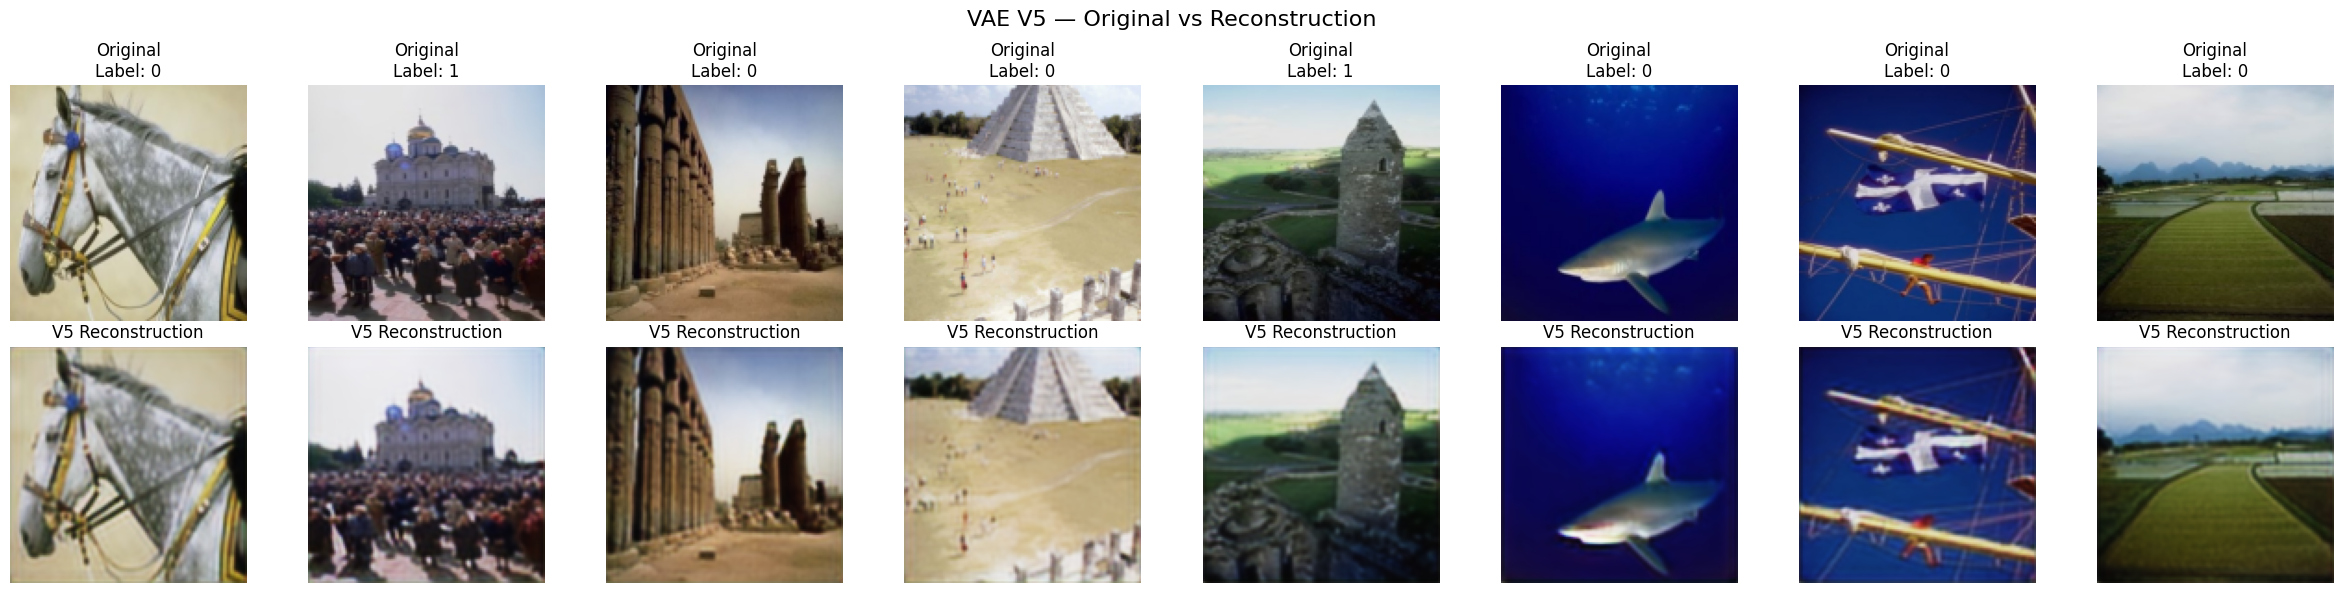

In [26]:
# ============================================================
# VAE V5 — RECONSTRUCTION VISUALIZATION
# Best checkpoint: Epoch 9
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import torch


# ------------------------------------------------------------
# Get one batch from validation set
# ------------------------------------------------------------

vae_v5.eval()

images, labels, paths = next(iter(val_loader))

images = images.to(DEVICE)


# ------------------------------------------------------------
# Reconstruction
# ------------------------------------------------------------

with torch.no_grad():

    reconstruction, mu, logvar = vae_v5(images)


# ------------------------------------------------------------
# Move to CPU
# ------------------------------------------------------------

images_cpu = images.cpu()
reconstruction_cpu = reconstruction.cpu()


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

num_images = min(8, images_cpu.size(0))

fig, axes = plt.subplots(
    2,
    num_images,
    figsize=(3 * num_images, 6)
)


for i in range(num_images):

    # Original
    original = (
        images_cpu[i]
        .permute(1, 2, 0)
        .numpy()
        .clip(0, 1)
    )

    # Reconstruction
    reconstructed = (
        reconstruction_cpu[i]
        .permute(1, 2, 0)
        .numpy()
        .clip(0, 1)
    )


    axes[0, i].imshow(original)
    axes[0, i].set_title(
        f"Original\nLabel: {labels[i]}"
    )
    axes[0, i].axis("off")


    axes[1, i].imshow(reconstructed)
    axes[1, i].set_title(
        "V5 Reconstruction"
    )
    axes[1, i].axis("off")


plt.suptitle(
    "VAE V5 — Original vs Reconstruction",
    fontsize=16
)

plt.tight_layout()
plt.show()

# VAE V5 — Reconstruction Error Map

The absolute pixel difference between the original and reconstructed images is visualized as a reconstruction-error map.

Bright regions indicate larger differences between the input and reconstruction.

These maps are useful for explaining model behavior and identifying regions that are difficult for the reconstruction model.

However, a reconstruction-error region should not automatically be interpreted as a tampered region.

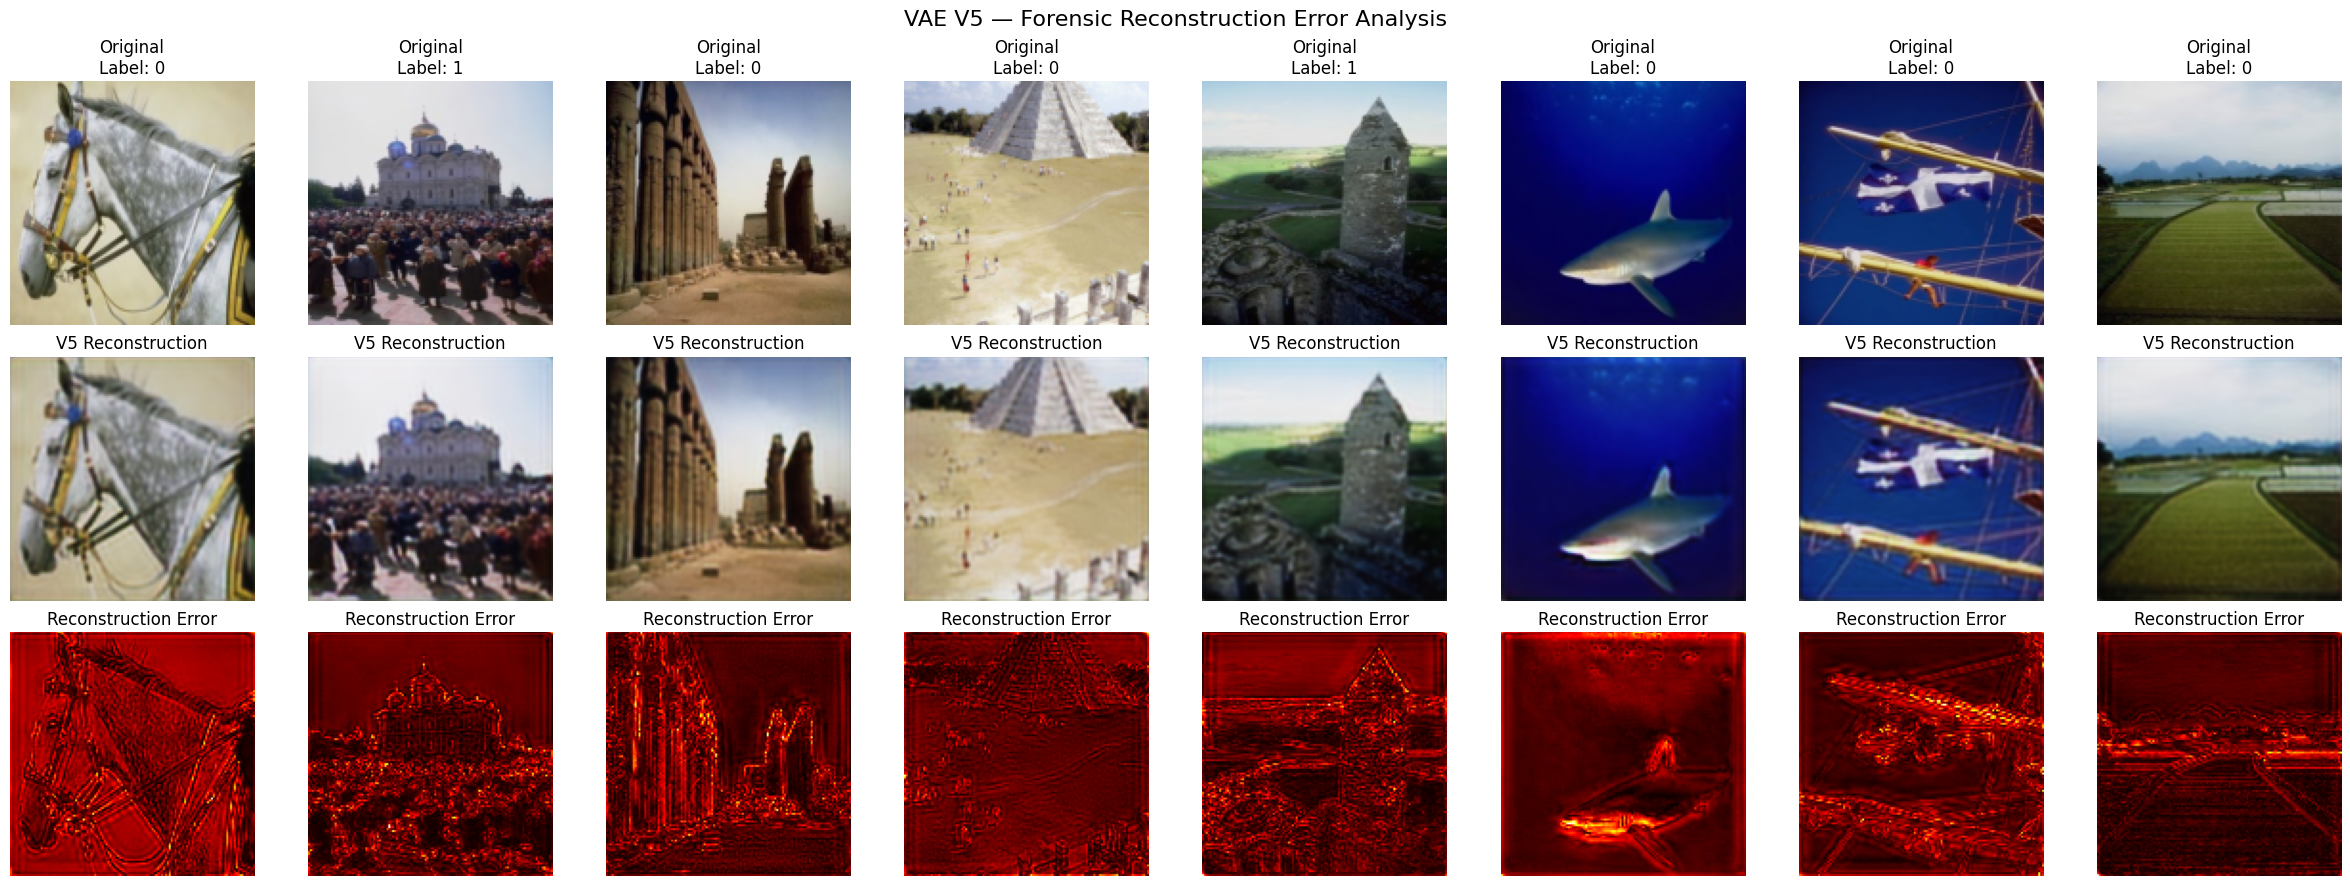

In [27]:
# ============================================================
# VAE V5 — FORENSIC DIFFERENCE MAP
# ============================================================

import matplotlib.pyplot as plt
import torch
import numpy as np

vae_v5.eval()

images, labels, paths = next(iter(val_loader))
images = images.to(DEVICE)

with torch.no_grad():
    reconstructions, mu, logvar = vae_v5(images)

images_cpu = images.cpu()
recon_cpu = reconstructions.cpu()

num_images = min(8, images_cpu.size(0))

fig, axes = plt.subplots(
    3,
    num_images,
    figsize=(3 * num_images, 9)
)

for i in range(num_images):

    original = (
        images_cpu[i]
        .permute(1, 2, 0)
        .numpy()
        .clip(0, 1)
    )

    reconstructed = (
        recon_cpu[i]
        .permute(1, 2, 0)
        .numpy()
        .clip(0, 1)
    )

    # Pixel-level absolute difference
    difference = np.abs(
        original - reconstructed
    )

    # Convert RGB difference to grayscale error
    error_map = difference.mean(axis=2)

    # Original
    axes[0, i].imshow(original)
    axes[0, i].set_title(
        f"Original\nLabel: {labels[i]}"
    )
    axes[0, i].axis("off")

    # Reconstruction
    axes[1, i].imshow(reconstructed)
    axes[1, i].set_title("V5 Reconstruction")
    axes[1, i].axis("off")

    # Difference
    axes[2, i].imshow(
        error_map,
        cmap="hot"
    )
    axes[2, i].set_title("Reconstruction Error")
    axes[2, i].axis("off")


plt.suptitle(
    "VAE V5 — Forensic Reconstruction Error Analysis",
    fontsize=16
)

plt.tight_layout()
plt.show()

# VAE V5 — Authentic vs Tampered Reconstruction Error

Per-image reconstruction MSE is calculated for the validation images.

The reconstruction errors are separated into:

- Authentic images
- Tampered images

The distributions are compared using:

- Mean MSE
- Median MSE
- Standard deviation
- Histogram
- ROC-AUC

This experiment investigates whether reconstruction error contains forensic information.

VAE V5 FORENSIC ERROR ANALYSIS

Authentic images : 1124
Tampered images  : 768

AUTHENTIC
Mean MSE : 0.002220
Median MSE : 0.001723
Std MSE : 0.002066

TAMPERED
Mean MSE : 0.002208
Median MSE : 0.001716
Std MSE : 0.002120

V5 Reconstruction-Error ROC-AUC : 0.4974


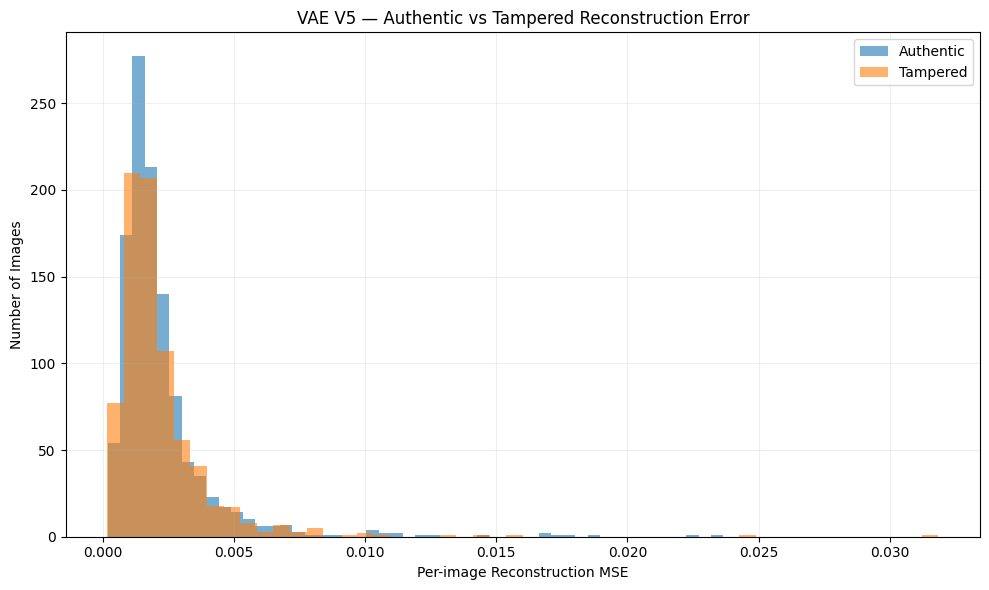

In [28]:
# ============================================================
# VAE V5 — AUTHENTIC vs TAMPERED RECONSTRUCTION ERROR
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ------------------------------------------------------------
# Best V5 model
# ------------------------------------------------------------

vae_v5.eval()

all_errors = []
all_labels = []
all_paths = []


# ------------------------------------------------------------
# Calculate per-image reconstruction error
# ------------------------------------------------------------

with torch.no_grad():

    for images, labels, paths in val_loader:

        images = images.to(DEVICE)

        reconstructions, mu, logvar = vae_v5(images)

        # Per-image MSE
        errors = (
            (reconstructions - images) ** 2
        ).mean(
            dim=(1, 2, 3)
        )

        all_errors.extend(
            errors.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
            if torch.is_tensor(labels)
            else np.array(labels)
        )

        all_paths.extend(paths)


# ------------------------------------------------------------
# Convert to arrays
# ------------------------------------------------------------

all_errors = np.array(all_errors)
all_labels = np.array(all_labels)


# ------------------------------------------------------------
# Separate authentic and tampered
# ------------------------------------------------------------

authentic_errors = all_errors[
    all_labels == 0
]

tampered_errors = all_errors[
    all_labels == 1
]


# ------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------

print("=" * 75)
print("VAE V5 FORENSIC ERROR ANALYSIS")
print("=" * 75)

print()
print("Authentic images :", len(authentic_errors))
print("Tampered images  :", len(tampered_errors))

print()
print("AUTHENTIC")
print(
    "Mean MSE :",
    f"{authentic_errors.mean():.6f}"
)
print(
    "Median MSE :",
    f"{np.median(authentic_errors):.6f}"
)
print(
    "Std MSE :",
    f"{authentic_errors.std():.6f}"
)

print()
print("TAMPERED")
print(
    "Mean MSE :",
    f"{tampered_errors.mean():.6f}"
)
print(
    "Median MSE :",
    f"{np.median(tampered_errors):.6f}"
)
print(
    "Std MSE :",
    f"{tampered_errors.std():.6f}"
)


# ------------------------------------------------------------
# ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    all_labels,
    all_errors
)

print()
print("=" * 75)
print(
    f"V5 Reconstruction-Error ROC-AUC : {roc_auc:.4f}"
)
print("=" * 75)


# ------------------------------------------------------------
# Distribution plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    authentic_errors,
    bins=50,
    alpha=0.6,
    label="Authentic"
)

plt.hist(
    tampered_errors,
    bins=50,
    alpha=0.6,
    label="Tampered"
)

plt.xlabel(
    "Per-image Reconstruction MSE"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "VAE V5 — Authentic vs Tampered Reconstruction Error"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

# VAE V5 Forensic Experiment — Authentic-Only Training

The previous V5 experiment used both authentic and tampered images during reconstruction training.

For forensic analysis, a separate experiment is performed using **authentic images only**.

The motivation is:

> If the VAE learns the reconstruction characteristics of authentic images, manipulated images may produce larger reconstruction discrepancies.

This is an anomaly-detection formulation rather than supervised binary classification.

Tampered images are therefore excluded from forensic V5 training.

# V5 Forensic Dataset — Authentic Only

Authentic images are selected from the existing training and validation splits.

The forensic training configuration uses:

- Authentic training images only
- Authentic validation images only
- No tampered images during training
- No tampered images during validation

The original test set remains untouched and contains both authentic and tampered images for final evaluation.

In [30]:
# ============================================================
# V5 FORENSIC EXPERIMENT
# AUTHENTIC-ONLY TRAINING DATA
# CORRECTED VERSION
# ============================================================

from torch.utils.data import DataLoader, Subset
import torch


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def get_label_as_int(label):

    if torch.is_tensor(label):
        return int(label.item())

    return int(label)


# ------------------------------------------------------------
# Find authentic samples
# Label 0 = Authentic
# Label 1 = Tampered
# ------------------------------------------------------------

print("Finding authentic training samples...")

train_authentic_indices = []

for i in range(len(train_dataset)):

    _, label, _ = train_dataset[i]

    if get_label_as_int(label) == 0:
        train_authentic_indices.append(i)


print("Finding authentic validation samples...")

val_authentic_indices = []

for i in range(len(val_dataset)):

    _, label, _ = val_dataset[i]

    if get_label_as_int(label) == 0:
        val_authentic_indices.append(i)


# ------------------------------------------------------------
# Create authentic-only subsets
# ------------------------------------------------------------

train_authentic_dataset = Subset(
    train_dataset,
    train_authentic_indices
)

val_authentic_dataset = Subset(
    val_dataset,
    val_authentic_indices
)


# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

BATCH_SIZE_V5_FORENSIC = 32

train_authentic_loader = DataLoader(
    train_authentic_dataset,
    batch_size=BATCH_SIZE_V5_FORENSIC,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_authentic_loader = DataLoader(
    val_authentic_dataset,
    batch_size=BATCH_SIZE_V5_FORENSIC,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# ------------------------------------------------------------
# Information
# ------------------------------------------------------------

print()
print("=" * 75)
print("V5 FORENSIC DATASET")
print("=" * 75)

print(
    "Original training images  :",
    len(train_dataset)
)

print(
    "Authentic training images :",
    len(train_authentic_dataset)
)

print(
    "Original validation images :",
    len(val_dataset)
)

print(
    "Authentic validation images:",
    len(val_authentic_dataset)
)

print()
print("Tampered images used for training   : 0")
print("Tampered images used for validation : 0")

print("=" * 75)
print("✓ Authentic-only loaders created")

Finding authentic training samples...
Finding authentic validation samples...

V5 FORENSIC DATASET
Original training images  : 8829
Authentic training images : 5243
Original validation images : 1892
Authentic validation images: 1124

Tampered images used for training   : 0
Tampered images used for validation : 0
✓ Authentic-only loaders created


In [31]:
# ============================================================
# VAE V5 — FORENSIC MODEL
# AUTHENTIC-ONLY TRAINING
# ============================================================

# Create a completely fresh V5 model
vae_v5_forensic = VAEV5(
    latent_dim=LATENT_DIM_V5
).to(DEVICE)


# ------------------------------------------------------------
# Verify parameter count
# ------------------------------------------------------------

params_v5_forensic = sum(
    p.numel()
    for p in vae_v5_forensic.parameters()
)


print("=" * 75)
print("VAE V5 FORENSIC MODEL READY")
print("=" * 75)

print(
    "Latent dimension :",
    LATENT_DIM_V5
)

print(
    "Total parameters :",
    f"{params_v5_forensic:,}"
)

print()
print("Training data    : AUTHENTIC ONLY")
print("Validation data  : AUTHENTIC ONLY")
print("Tampered training: 0")
print("Tampered validation: 0")

print("=" * 75)
print("✓ Fresh forensic V5 created")

VAE V5 FORENSIC MODEL READY
Latent dimension : 256
Total parameters : 17,599,971

Training data    : AUTHENTIC ONLY
Validation data  : AUTHENTIC ONLY
Tampered training: 0
Tampered validation: 0
✓ Fresh forensic V5 created


# VAE V5 Forensic Model

A completely fresh V5 model is initialized for the authentic-only experiment.

This is important because the model must not inherit parameters learned from the earlier mixed-data V5 experiment.

The forensic model therefore learns reconstruction behavior exclusively from authentic training images.

# VAE V5 Forensic Training — Authentic Only

The forensic V5 model is trained for 80 epochs.

Early stopping is disabled.

The best checkpoint is selected using the lowest reconstruction MSE on the authentic validation set.

Training configuration:

- 80 epochs
- AdamW optimizer
- Learning rate: 1 × 10⁻⁴
- Weight decay: 1 × 10⁻⁵
- KL warm-up: 20 epochs
- Gradient clipping
- ReduceLROnPlateau

The purpose is to learn a strong reconstruction model of authentic evidence.

In [32]:
# ============================================================
# VAE V5 FORENSIC TRAINING
# AUTHENTIC-ONLY
# 80 EPOCHS — NO EARLY STOPPING
# ============================================================

import math
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm


# ------------------------------------------------------------
# Fresh optimizer
# ------------------------------------------------------------

optimizer_v5_forensic = torch.optim.AdamW(
    vae_v5_forensic.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)


# ------------------------------------------------------------
# Scheduler
# ------------------------------------------------------------

scheduler_v5_forensic = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v5_forensic,
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

EPOCHS_V5_FORENSIC = 80

KL_WARMUP_EPOCHS_V5_FORENSIC = 20

BETA_START_V5_FORENSIC = 0.00005
BETA_END_V5_FORENSIC = 0.00030

L1_WEIGHT_V5_FORENSIC = 0.5

GRAD_CLIP_V5_FORENSIC = 1.0


# ------------------------------------------------------------
# Checkpoint
# ------------------------------------------------------------

BEST_V5_FORENSIC_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "best_vae_v5_forensic.pth"
)

BEST_V5_FORENSIC_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# History
# ------------------------------------------------------------

history_v5_forensic = {
    "train_total": [],
    "val_total": [],

    "train_mse": [],
    "val_mse": [],

    "train_l1": [],
    "val_l1": [],

    "train_kl": [],
    "val_kl": [],

    "val_psnr": [],

    "beta": [],
    "lr": []
}


# ------------------------------------------------------------
# Best validation MSE
# ------------------------------------------------------------

best_val_mse_v5_forensic = float("inf")
best_epoch_v5_forensic = 0


print("=" * 80)
print("STARTING V5 FORENSIC TRAINING")
print("=" * 80)

print("Training data       : AUTHENTIC ONLY")
print("Validation data     : AUTHENTIC ONLY")
print("Tampered train      : 0")
print("Tampered validation : 0")
print("Epochs              :", EPOCHS_V5_FORENSIC)
print("Early stopping      : DISABLED")
print("KL warm-up          :", KL_WARMUP_EPOCHS_V5_FORENSIC)
print("Latent dimension    :", LATENT_DIM_V5)

print("=" * 80)


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(
    1,
    EPOCHS_V5_FORENSIC + 1
):


    # --------------------------------------------------------
    # KL warm-up
    # --------------------------------------------------------

    if epoch <= KL_WARMUP_EPOCHS_V5_FORENSIC:

        beta = (
            BETA_START_V5_FORENSIC
            +
            (
                BETA_END_V5_FORENSIC
                - BETA_START_V5_FORENSIC
            )
            *
            (epoch - 1)
            /
            max(
                KL_WARMUP_EPOCHS_V5_FORENSIC - 1,
                1
            )
        )

    else:

        beta = BETA_END_V5_FORENSIC


    # ========================================================
    # TRAIN
    # ========================================================

    vae_v5_forensic.train()

    train_total = 0.0
    train_mse = 0.0
    train_l1 = 0.0
    train_kl = 0.0


    for images, _, _ in tqdm(
        train_authentic_loader,
        desc=f"Epoch {epoch:02d}/{EPOCHS_V5_FORENSIC}",
        leave=False
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        optimizer_v5_forensic.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        reconstruction, mu, logvar = (
            vae_v5_forensic(images)
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        losses = vae_v5_loss(
            reconstruction,
            images,
            mu,
            logvar,
            beta=beta,
            l1_weight=L1_WEIGHT_V5_FORENSIC
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        losses["total"].backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            vae_v5_forensic.parameters(),
            GRAD_CLIP_V5_FORENSIC
        )


        optimizer_v5_forensic.step()


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        batch_size = images.size(0)

        train_total += (
            losses["total"].item()
            * batch_size
        )

        train_mse += (
            losses["mse"].item()
            * batch_size
        )

        train_l1 += (
            losses["l1"].item()
            * batch_size
        )

        train_kl += (
            losses["kl"].item()
            * batch_size
        )


    # --------------------------------------------------------
    # Average training metrics
    # --------------------------------------------------------

    train_total /= len(
        train_authentic_dataset
    )

    train_mse /= len(
        train_authentic_dataset
    )

    train_l1 /= len(
        train_authentic_dataset
    )

    train_kl /= len(
        train_authentic_dataset
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    vae_v5_forensic.eval()

    val_total = 0.0
    val_mse = 0.0
    val_l1 = 0.0
    val_kl = 0.0


    with torch.no_grad():

        for images, _, _ in val_authentic_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )


            # ------------------------------------------------
            # Deterministic reconstruction
            # ------------------------------------------------

            mu, logvar, e1, e2, e3, e4 = (
                vae_v5_forensic.encode(images)
            )

            reconstruction = (
                vae_v5_forensic.decode(
                    mu,
                    e1,
                    e2,
                    e3,
                    e4
                )
            )


            # ------------------------------------------------
            # MSE
            # ------------------------------------------------

            mse = F.mse_loss(
                reconstruction,
                images,
                reduction="mean"
            )


            # ------------------------------------------------
            # L1
            # ------------------------------------------------

            l1 = F.l1_loss(
                reconstruction,
                images,
                reduction="mean"
            )


            # ------------------------------------------------
            # Reconstruction loss
            # ------------------------------------------------

            reconstruction_loss = (
                (1.0 - L1_WEIGHT_V5_FORENSIC)
                * mse
                +
                L1_WEIGHT_V5_FORENSIC
                * l1
            )


            # ------------------------------------------------
            # KL
            # ------------------------------------------------

            kl = -0.5 * torch.mean(
                torch.sum(
                    1
                    + logvar
                    - mu.pow(2)
                    - logvar.exp(),
                    dim=1
                )
            )


            # ------------------------------------------------
            # Total
            # ------------------------------------------------

            total = (
                reconstruction_loss
                + beta * kl
            )


            batch_size = images.size(0)

            val_total += (
                total.item()
                * batch_size
            )

            val_mse += (
                mse.item()
                * batch_size
            )

            val_l1 += (
                l1.item()
                * batch_size
            )

            val_kl += (
                kl.item()
                * batch_size
            )


    # --------------------------------------------------------
    # Average validation metrics
    # --------------------------------------------------------

    val_total /= len(
        val_authentic_dataset
    )

    val_mse /= len(
        val_authentic_dataset
    )

    val_l1 /= len(
        val_authentic_dataset
    )

    val_kl /= len(
        val_authentic_dataset
    )


    # ========================================================
    # PSNR
    # ========================================================

    val_psnr = -10.0 * math.log10(
        max(val_mse, 1e-12)
    )


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler_v5_forensic.step(
        val_mse
    )

    current_lr = (
        optimizer_v5_forensic
        .param_groups[0]["lr"]
    )


    # ========================================================
    # HISTORY
    # ========================================================

    history_v5_forensic[
        "train_total"
    ].append(train_total)

    history_v5_forensic[
        "val_total"
    ].append(val_total)

    history_v5_forensic[
        "train_mse"
    ].append(train_mse)

    history_v5_forensic[
        "val_mse"
    ].append(val_mse)

    history_v5_forensic[
        "train_l1"
    ].append(train_l1)

    history_v5_forensic[
        "val_l1"
    ].append(val_l1)

    history_v5_forensic[
        "train_kl"
    ].append(train_kl)

    history_v5_forensic[
        "val_kl"
    ].append(val_kl)

    history_v5_forensic[
        "val_psnr"
    ].append(val_psnr)

    history_v5_forensic[
        "beta"
    ].append(beta)

    history_v5_forensic[
        "lr"
    ].append(current_lr)


    # ========================================================
    # SAVE BEST CHECKPOINT
    # ========================================================

    improved = (
        val_mse
        <
        best_val_mse_v5_forensic
    )


    if improved:

        best_val_mse_v5_forensic = val_mse
        best_epoch_v5_forensic = epoch


        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    vae_v5_forensic.state_dict(),

                "optimizer_state_dict":
                    optimizer_v5_forensic.state_dict(),

                "scheduler_state_dict":
                    scheduler_v5_forensic.state_dict(),

                "val_mse":
                    val_mse,

                "val_psnr":
                    val_psnr,

                "val_l1":
                    val_l1,

                "val_kl":
                    val_kl,

                "latent_dim":
                    LATENT_DIM_V5,

                "image_size":
                    IMAGE_SIZE,

                "l1_weight":
                    L1_WEIGHT_V5_FORENSIC,

                "beta":
                    beta
            },
            BEST_V5_FORENSIC_PATH
        )


    # ========================================================
    # EPOCH REPORT
    # ========================================================

    print(
        f"Epoch {epoch:02d} | "
        f"Train MSE: {train_mse:.5f} | "
        f"Val MSE: {val_mse:.5f} | "
        f"PSNR: {val_psnr:.2f} dB | "
        f"Val KL: {val_kl:.4f} | "
        f"β: {beta:.5f} | "
        f"LR: {current_lr:.2e}"
        + (
            "  ★ BEST"
            if improved
            else ""
        )
    )


# ============================================================
# FINAL REPORT
# ============================================================

print("\n" + "=" * 80)
print("V5 FORENSIC TRAINING COMPLETE")
print("=" * 80)

print(
    "Total epochs trained :",
    EPOCHS_V5_FORENSIC
)

print(
    "Best epoch           :",
    best_epoch_v5_forensic
)

print(
    "Best validation MSE  :",
    f"{best_val_mse_v5_forensic:.6f}"
)

print(
    "Best validation PSNR :",
    f"{-10.0 * math.log10(max(best_val_mse_v5_forensic, 1e-12)):.2f} dB"
)

print(
    "Best checkpoint      :",
    BEST_V5_FORENSIC_PATH
)

print()
print("✓ 80 epochs completed")
print("✓ Authentic-only training used")
print("✓ No tampered images used during training")
print("✓ No early stopping")
print("✓ Best validation checkpoint preserved")

STARTING V5 FORENSIC TRAINING
Training data       : AUTHENTIC ONLY
Validation data     : AUTHENTIC ONLY
Tampered train      : 0
Tampered validation : 0
Epochs              : 80
Early stopping      : DISABLED
KL warm-up          : 20
Latent dimension    : 256


Epoch 01/80:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 01 | Train MSE: 0.01577 | Val MSE: 0.00815 | PSNR: 20.89 dB | Val KL: 0.7852 | β: 0.00005 | LR: 1.00e-04  ★ BEST


Epoch 02/80:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 02 | Train MSE: 0.00633 | Val MSE: 0.00553 | PSNR: 22.57 dB | Val KL: 0.4475 | β: 0.00006 | LR: 1.00e-04  ★ BEST


...

Epoch 78 | Train MSE: 0.00099 | Val MSE: 0.00277 | PSNR: 25.58 dB | Val KL: 0.3784 | β: 0.00030 | LR: 1.00e-06


Epoch 79/80:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 79 | Train MSE: 0.00099 | Val MSE: 0.00281 | PSNR: 25.51 dB | Val KL: 0.3819 | β: 0.00030 | LR: 1.00e-06


Epoch 80/80:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 80 | Train MSE: 0.00099 | Val MSE: 0.00266 | PSNR: 25.75 dB | Val KL: 0.3772 | β: 0.00030 | LR: 1.00e-06

V5 FORENSIC TRAINING COMPLETE
Total epochs trained : 80
Best epoch           : 18
Best validation MSE  : 0.002313
Best validation PSNR : 26.36 dB
Best checkpoint      : /content/AI-Digital-Evidence-Intelligence-Platform/checkpoints/best_vae_v5_forensic.pth

✓ 80 epochs completed
✓ Authentic-only training used
✓ No tampered images used during training
✓ No early stopping
✓ Best validation checkpoint preserved


# VAE V5 — Load Best Forensic Checkpoint

The best authentic-only V5 checkpoint is loaded.

The selected checkpoint corresponds to:

- Best epoch: 18
- Validation MSE: 0.002313
- Validation PSNR: 26.36 dB

This frozen model is used for the final forensic experiments.

In [33]:
# ============================================================
# LOAD BEST FORENSIC V5 CHECKPOINT
# ============================================================

BEST_VAE_V5_FORENSIC_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "best_vae_v5_forensic.pth"
)

checkpoint_v5_forensic = torch.load(
    BEST_VAE_V5_FORENSIC_PATH,
    map_location=DEVICE
)

vae_v5_forensic.load_state_dict(
    checkpoint_v5_forensic["model_state_dict"]
)

vae_v5_forensic.to(DEVICE)
vae_v5_forensic.eval()


print("=" * 75)
print("BEST FORENSIC V5 CHECKPOINT LOADED")
print("=" * 75)

print(
    "Checkpoint epoch :",
    checkpoint_v5_forensic["epoch"]
)

print(
    "Validation MSE   :",
    f"{checkpoint_v5_forensic['val_mse']:.6f}"
)

print(
    "Validation PSNR  :",
    f"{checkpoint_v5_forensic['val_psnr']:.2f} dB"
)

print(
    "Training data    : AUTHENTIC ONLY"
)

print("=" * 75)
print("✓ Best forensic V5 model is now active")

BEST FORENSIC V5 CHECKPOINT LOADED
Checkpoint epoch : 18
Validation MSE   : 0.002313
Validation PSNR  : 26.36 dB
Training data    : AUTHENTIC ONLY
✓ Best forensic V5 model is now active


# V5 Forensic Evaluation — Untouched Test Set

The authentic-only V5 model is evaluated on the untouched test set.

The test set contains:

- 1,124 authentic images
- 769 tampered images
- 1,893 total images

For each image, reconstruction MSE is calculated.

ROC-AUC is then used to measure whether reconstruction error can distinguish authentic from tampered images.

A ROC-AUC of 0.5 represents random ranking, while larger values indicate stronger separation.

VAE V5 FORENSIC TEST EVALUATION

Total test images : 1893
Authentic         : 1124
Tampered          : 769

AUTHENTIC
Mean MSE   : 0.002254
Median MSE : 0.001620
Std MSE    : 0.002405
Min MSE    : 0.000172
Max MSE    : 0.030560

TAMPERED
Mean MSE   : 0.002702
Median MSE : 0.002041
Std MSE    : 0.002253
Min MSE    : 0.000296
Max MSE    : 0.023500

FORENSIC ROC-AUC : 0.6008


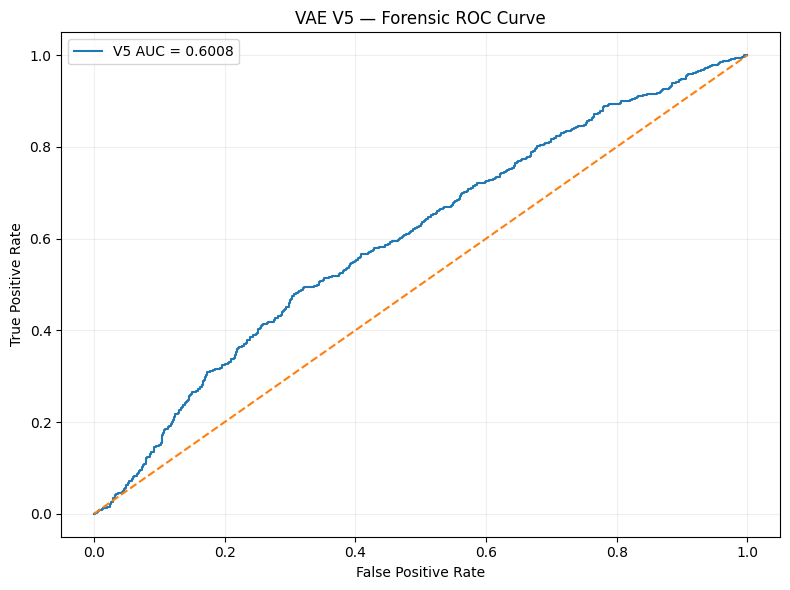

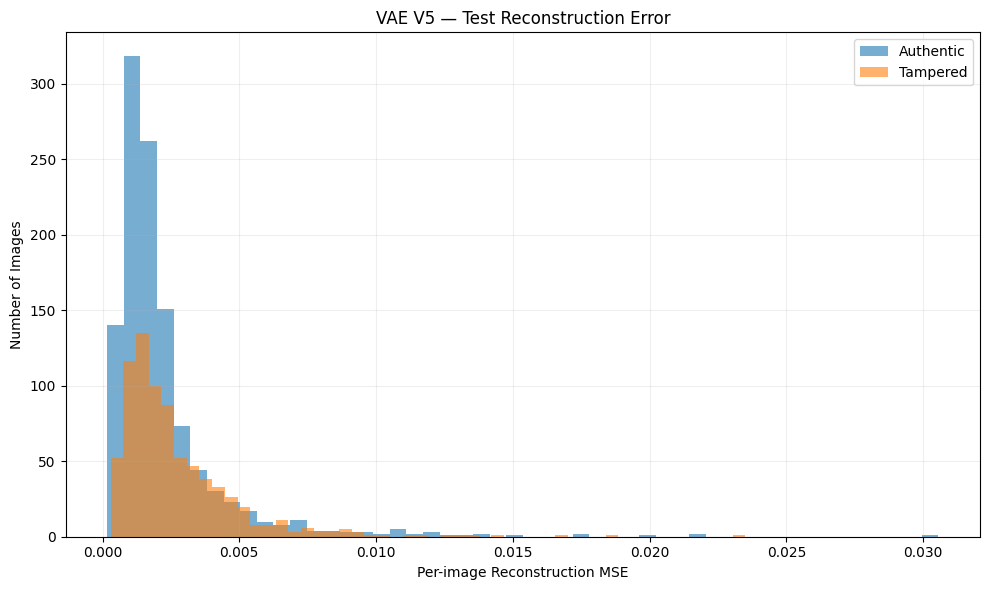

In [34]:
# ============================================================
# V5 FORENSIC EVALUATION
# UNTOUCHED TEST SET
# Authentic vs Tampered
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)


# ------------------------------------------------------------
# Best forensic V5
# ------------------------------------------------------------

vae_v5_forensic.eval()

all_errors = []
all_labels = []
all_paths = []


# ------------------------------------------------------------
# Evaluate test set
# ------------------------------------------------------------

with torch.no_grad():

    for images, labels, paths in val_loader.__class__(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        reconstruction, mu, logvar = (
            vae_v5_forensic(images)
        )

        # Per-image reconstruction MSE
        errors = (
            (reconstruction - images) ** 2
        ).mean(
            dim=(1, 2, 3)
        )

        all_errors.extend(
            errors.cpu().numpy()
        )

        if torch.is_tensor(labels):
            all_labels.extend(
                labels.cpu().numpy()
            )
        else:
            all_labels.extend(
                np.asarray(labels)
            )

        all_paths.extend(paths)


# ------------------------------------------------------------
# Convert to numpy
# ------------------------------------------------------------

all_errors = np.asarray(
    all_errors,
    dtype=np.float32
)

all_labels = np.asarray(
    all_labels,
    dtype=np.int64
)


# ------------------------------------------------------------
# Verify test set
# ------------------------------------------------------------

authentic_errors = all_errors[
    all_labels == 0
]

tampered_errors = all_errors[
    all_labels == 1
]


print("=" * 75)
print("VAE V5 FORENSIC TEST EVALUATION")
print("=" * 75)

print()
print("Total test images :", len(all_errors))
print("Authentic         :", len(authentic_errors))
print("Tampered          :", len(tampered_errors))


# ------------------------------------------------------------
# Error statistics
# ------------------------------------------------------------

print()
print("AUTHENTIC")
print(
    f"Mean MSE   : {authentic_errors.mean():.6f}"
)
print(
    f"Median MSE : {np.median(authentic_errors):.6f}"
)
print(
    f"Std MSE    : {authentic_errors.std():.6f}"
)
print(
    f"Min MSE    : {authentic_errors.min():.6f}"
)
print(
    f"Max MSE    : {authentic_errors.max():.6f}"
)


print()
print("TAMPERED")
print(
    f"Mean MSE   : {tampered_errors.mean():.6f}"
)
print(
    f"Median MSE : {np.median(tampered_errors):.6f}"
)
print(
    f"Std MSE    : {tampered_errors.std():.6f}"
)
print(
    f"Min MSE    : {tampered_errors.min():.6f}"
)
print(
    f"Max MSE    : {tampered_errors.max():.6f}"
)


# ------------------------------------------------------------
# ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    all_labels,
    all_errors
)

print()
print("=" * 75)
print(
    f"FORENSIC ROC-AUC : {roc_auc:.4f}"
)
print("=" * 75)


# ------------------------------------------------------------
# ROC curve
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_errors
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"V5 AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "VAE V5 — Forensic ROC Curve"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Distribution
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    authentic_errors,
    bins=50,
    alpha=0.6,
    label="Authentic"
)

plt.hist(
    tampered_errors,
    bins=50,
    alpha=0.6,
    label="Tampered"
)

plt.xlabel(
    "Per-image Reconstruction MSE"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "VAE V5 — Test Reconstruction Error"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

# V5 Forensic Development — MSE + SSIM

Reconstruction quality is analyzed using two complementary signals:

### MSE
Measures pixel-level reconstruction difference.

Higher MSE indicates a larger pixel-level discrepancy.

### SSIM
Measures structural similarity between the original and reconstructed images.

For anomaly analysis, SSIM error is defined as:

SSIM Error = 1 − SSIM

Higher SSIM error indicates lower structural similarity.

Both signals are evaluated on the validation set before any final test scoring rule is selected.

In [35]:
# ============================================================
# V5 FORENSIC DEVELOPMENT
# MSE + SSIM ON VALIDATION SET
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from skimage.metrics import structural_similarity


# ------------------------------------------------------------
# Best forensic V5
# ------------------------------------------------------------

vae_v5_forensic.eval()


all_mse_val = []
all_ssim_val = []
all_labels_val = []
all_paths_val = []


# ------------------------------------------------------------
# Evaluate validation set
# ------------------------------------------------------------

for images, labels, paths in val_loader:

    images = images.to(
        DEVICE,
        non_blocking=True
    )

    with torch.no_grad():

        # Deterministic VAE reconstruction
        mu, logvar, e1, e2, e3, e4 = (
            vae_v5_forensic.encode(images)
        )

        reconstructions = (
            vae_v5_forensic.decode(
                mu,
                e1,
                e2,
                e3,
                e4
            )
        )


    # --------------------------------------------------------
    # Per-image MSE
    # --------------------------------------------------------

    mse_batch = (
        (reconstructions - images) ** 2
    ).mean(
        dim=(1, 2, 3)
    )


    # --------------------------------------------------------
    # Convert to CPU numpy
    # --------------------------------------------------------

    images_np = (
        images
        .detach()
        .cpu()
        .permute(0, 2, 3, 1)
        .numpy()
    )

    recon_np = (
        reconstructions
        .detach()
        .cpu()
        .permute(0, 2, 3, 1)
        .numpy()
    )


    # --------------------------------------------------------
    # Per-image SSIM
    # --------------------------------------------------------

    for i in range(
        images_np.shape[0]
    ):

        ssim_value = structural_similarity(
            images_np[i],
            recon_np[i],
            channel_axis=2,
            data_range=1.0
        )

        all_ssim_val.append(
            ssim_value
        )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    all_mse_val.extend(
        mse_batch.cpu().numpy()
    )

    if torch.is_tensor(labels):

        all_labels_val.extend(
            labels.cpu().numpy()
        )

    else:

        all_labels_val.extend(
            np.asarray(labels)
        )

    all_paths_val.extend(paths)


# ------------------------------------------------------------
# Convert to numpy
# ------------------------------------------------------------

all_mse_val = np.asarray(
    all_mse_val,
    dtype=np.float32
)

all_ssim_val = np.asarray(
    all_ssim_val,
    dtype=np.float32
)

all_labels_val = np.asarray(
    all_labels_val,
    dtype=np.int64
)


# ------------------------------------------------------------
# SSIM anomaly score
# Higher = more abnormal
# ------------------------------------------------------------

all_ssim_error_val = (
    1.0 - all_ssim_val
)


# ------------------------------------------------------------
# Separate authentic / tampered
# ------------------------------------------------------------

auth_mse = all_mse_val[
    all_labels_val == 0
]

tam_mse = all_mse_val[
    all_labels_val == 1
]

auth_ssim = all_ssim_val[
    all_labels_val == 0
]

tam_ssim = all_ssim_val[
    all_labels_val == 1
]

auth_ssim_error = all_ssim_error_val[
    all_labels_val == 0
]

tam_ssim_error = all_ssim_error_val[
    all_labels_val == 1
]


# ============================================================
# REPORT
# ============================================================

print("=" * 75)
print("V5 FORENSIC VALIDATION — MSE + SSIM")
print("=" * 75)

print()
print("Total validation images :", len(all_mse_val))
print("Authentic               :", len(auth_mse))
print("Tampered                :", len(tam_mse))


# ------------------------------------------------------------
# MSE
# ------------------------------------------------------------

print()
print("MSE")
print("-" * 75)

print(
    f"Authentic mean   : {auth_mse.mean():.6f}"
)

print(
    f"Tampered mean    : {tam_mse.mean():.6f}"
)


# ------------------------------------------------------------
# SSIM
# ------------------------------------------------------------

print()
print("SSIM")
print("-" * 75)

print(
    f"Authentic mean   : {auth_ssim.mean():.6f}"
)

print(
    f"Tampered mean    : {tam_ssim.mean():.6f}"
)


# ------------------------------------------------------------
# SSIM anomaly score
# ------------------------------------------------------------

print()
print("SSIM ANOMALY SCORE = 1 - SSIM")
print("-" * 75)

print(
    f"Authentic mean   : {auth_ssim_error.mean():.6f}"
)

print(
    f"Tampered mean    : {tam_ssim_error.mean():.6f}"
)


# ============================================================
# ROC-AUC
# ============================================================

from sklearn.metrics import roc_auc_score


mse_auc_val = roc_auc_score(
    all_labels_val,
    all_mse_val
)

ssim_auc_val = roc_auc_score(
    all_labels_val,
    all_ssim_error_val
)


print()
print("=" * 75)

print(
    f"MSE ROC-AUC          : {mse_auc_val:.4f}"
)

print(
    f"SSIM-error ROC-AUC   : {ssim_auc_val:.4f}"
)

print("=" * 75)

V5 FORENSIC VALIDATION — MSE + SSIM

Total validation images : 1892
Authentic               : 1124
Tampered                : 768

MSE
---------------------------------------------------------------------------
Authentic mean   : 0.002313
Tampered mean    : 0.002543

SSIM
---------------------------------------------------------------------------
Authentic mean   : 0.910628
Tampered mean    : 0.905997

SSIM ANOMALY SCORE = 1 - SSIM
---------------------------------------------------------------------------
Authentic mean   : 0.089372
Tampered mean    : 0.094003

MSE ROC-AUC          : 0.5291
SSIM-error ROC-AUC   : 0.5408


# V5 Forensic Development — Combined MSE + SSIM

Normalized MSE and SSIM-error scores are combined to investigate whether the two signals provide complementary forensic information.

The combined score is:

Combined Score =
α × MSE +
(1 − α) × SSIM Error

The weight α is optimized using the validation set only.

The test set is not used to select the weight.

This preserves the independence of the final test evaluation.

V5 COMBINED FORENSIC SCORE
Validation samples : 1892
MSE available      : 1892
SSIM available     : 1892

Individual validation performance
---------------------------------------------------------------------------
MSE ROC-AUC        : 0.5291
SSIM-error ROC-AUC : 0.5408

BEST COMBINED SCORE
Best MSE weight  : 0.30
Best SSIM weight : 0.70
Best ROC-AUC     : 0.5430

VALIDATION COMPARISON
---------------------------------------------------------------------------
MSE only         : 0.5291
SSIM-error only  : 0.5408
MSE + SSIM       : 0.5430

Improvement over MSE  : +0.0139
Improvement over SSIM : +0.0022


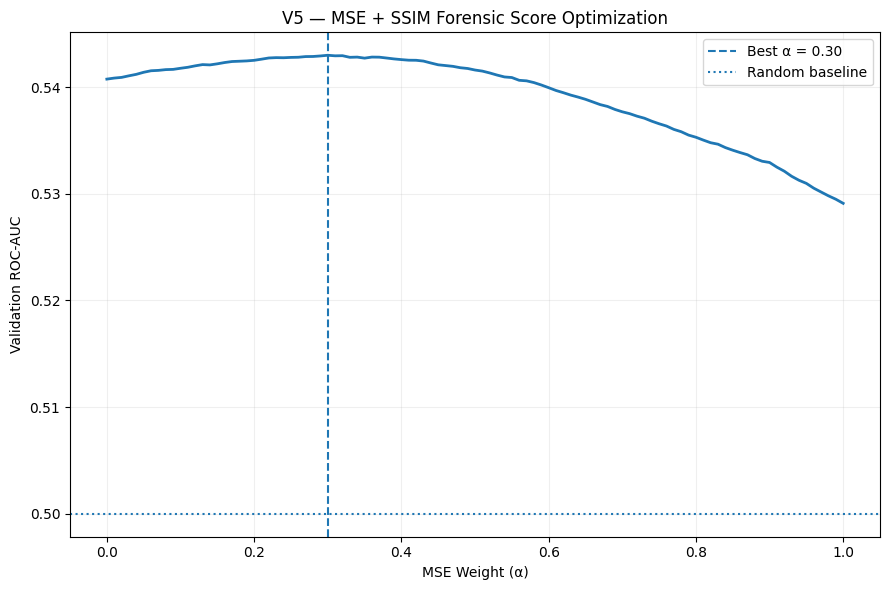

In [36]:
# ============================================================
# V5 FORENSIC DEVELOPMENT
# COMBINED MSE + SSIM-ERROR SCORE
# VALIDATION SET ONLY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# Check required variables
# ------------------------------------------------------------

print("=" * 75)
print("V5 COMBINED FORENSIC SCORE")
print("=" * 75)

print("Validation samples :", len(all_mse_val))
print("MSE available      :", len(all_mse_val))
print("SSIM available     :", len(all_ssim_val))


# ============================================================
# NORMALIZE SCORES
# ============================================================

def min_max_normalize(values):

    values = np.asarray(
        values,
        dtype=np.float64
    )

    minimum = values.min()
    maximum = values.max()

    if maximum - minimum < 1e-12:
        return np.zeros_like(values)

    return (
        (values - minimum)
        / (maximum - minimum)
    )


# ------------------------------------------------------------
# MSE anomaly score
# Higher = more anomalous
# ------------------------------------------------------------

mse_score_val = min_max_normalize(
    all_mse_val
)


# ------------------------------------------------------------
# SSIM anomaly score
# Higher = more anomalous
# ------------------------------------------------------------

ssim_error_val = (
    1.0 - all_ssim_val
)

ssim_score_val = min_max_normalize(
    ssim_error_val
)


# ============================================================
# INDIVIDUAL BASELINES
# ============================================================

mse_auc = roc_auc_score(
    all_labels_val,
    mse_score_val
)

ssim_auc = roc_auc_score(
    all_labels_val,
    ssim_score_val
)


print()
print("Individual validation performance")
print("-" * 75)

print(
    f"MSE ROC-AUC        : {mse_auc:.4f}"
)

print(
    f"SSIM-error ROC-AUC : {ssim_auc:.4f}"
)


# ============================================================
# SEARCH BEST COMBINATION
# ============================================================

weights = np.linspace(
    0.0,
    1.0,
    101
)

results = []

best_auc = -1.0
best_alpha = 0.5
best_score = None


for alpha in weights:

    combined_score = (
        alpha * mse_score_val
        + (1.0 - alpha)
        * ssim_score_val
    )

    auc = roc_auc_score(
        all_labels_val,
        combined_score
    )

    results.append(
        {
            "alpha_mse": alpha,
            "alpha_ssim": 1.0 - alpha,
            "roc_auc": auc
        }
    )


    if auc > best_auc:

        best_auc = auc
        best_alpha = alpha
        best_score = combined_score.copy()


# ============================================================
# RESULTS
# ============================================================

print()
print("=" * 75)
print("BEST COMBINED SCORE")
print("=" * 75)

print(
    f"Best MSE weight  : {best_alpha:.2f}"
)

print(
    f"Best SSIM weight : {1.0 - best_alpha:.2f}"
)

print(
    f"Best ROC-AUC     : {best_auc:.4f}"
)

print("=" * 75)


# ============================================================
# COMPARE
# ============================================================

print()
print("VALIDATION COMPARISON")
print("-" * 75)

print(
    f"MSE only         : {mse_auc:.4f}"
)

print(
    f"SSIM-error only  : {ssim_auc:.4f}"
)

print(
    f"MSE + SSIM       : {best_auc:.4f}"
)


improvement_over_mse = (
    best_auc - mse_auc
)

improvement_over_ssim = (
    best_auc - ssim_auc
)

print()
print(
    f"Improvement over MSE  : "
    f"{improvement_over_mse:+.4f}"
)

print(
    f"Improvement over SSIM : "
    f"{improvement_over_ssim:+.4f}"
)


# ============================================================
# WEIGHT SEARCH CURVE
# ============================================================

result_weights = np.array(
    [r["alpha_mse"] for r in results]
)

result_auc = np.array(
    [r["roc_auc"] for r in results]
)


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    result_weights,
    result_auc,
    linewidth=2
)

plt.axvline(
    best_alpha,
    linestyle="--",
    label=f"Best α = {best_alpha:.2f}"
)

plt.axhline(
    0.5,
    linestyle=":",
    label="Random baseline"
)

plt.xlabel(
    "MSE Weight (α)"
)

plt.ylabel(
    "Validation ROC-AUC"
)

plt.title(
    "V5 — MSE + SSIM Forensic Score Optimization"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

# V5 — Final Frozen MSE + SSIM Test

The validation experiment selected:

- MSE weight: 0.30
- SSIM-error weight: 0.70

These weights are frozen before testing.

The final test evaluates:

1. MSE only
2. SSIM-error only
3. MSE + SSIM

The test set is used only for final measurement and not for further parameter tuning.

FINAL V5 FORENSIC TEST

Total test images : 1893
Authentic         : 1124
Tampered          : 769

AUTHENTIC
---------------------------------------------------------------------------
Mean MSE       : 0.002346
Mean SSIM      : 0.910806
Mean Combined  : 0.185462

TAMPERED
---------------------------------------------------------------------------
Mean MSE       : 0.002551
Mean SSIM      : 0.904356
Mean Combined  : 0.202403

FINAL TEST ROC-AUC
MSE only        : 0.5518
SSIM-error only : 0.5576
MSE + SSIM      : 0.5570

Frozen weights:
MSE  = 0.30
SSIM = 0.70


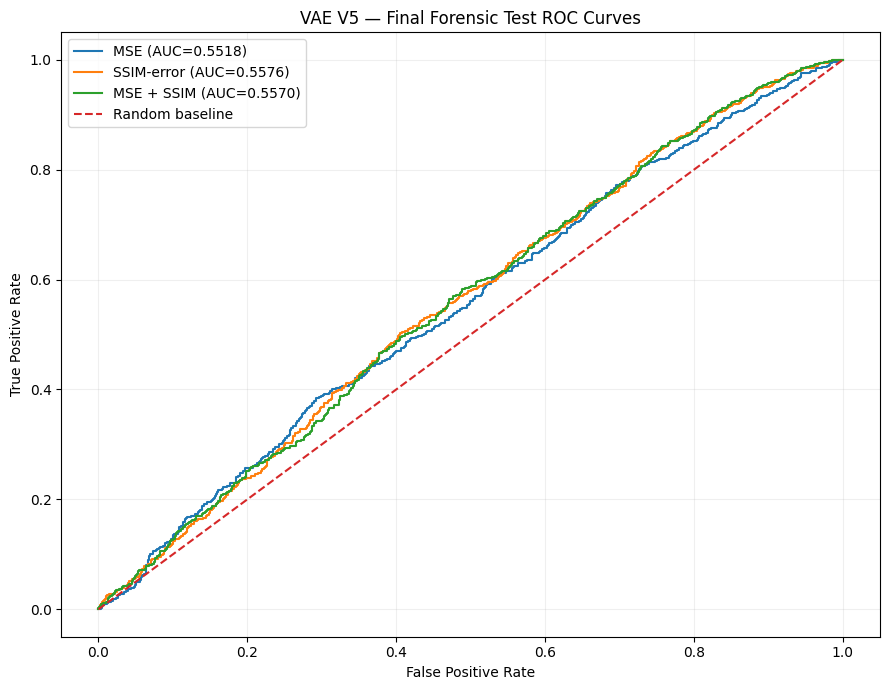

In [37]:
# ============================================================
# FINAL V5 FORENSIC TEST
# FROZEN MSE + SSIM SCORE
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)
from torch.utils.data import DataLoader
from skimage.metrics import structural_similarity


# ------------------------------------------------------------
# FINAL FROZEN WEIGHTS
# Selected ONLY using validation data
# ------------------------------------------------------------

ALPHA_MSE_FINAL = 0.30
ALPHA_SSIM_FINAL = 0.70


# ------------------------------------------------------------
# Test loader
# ------------------------------------------------------------

test_loader_final = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# ------------------------------------------------------------
# Best forensic V5
# ------------------------------------------------------------

vae_v5_forensic.eval()


all_test_mse = []
all_test_ssim = []
all_test_labels = []
all_test_paths = []


# ============================================================
# TEST EVALUATION
# ============================================================

with torch.no_grad():

    for images, labels, paths in test_loader_final:

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Deterministic reconstruction
        # ----------------------------------------------------

        mu, logvar, e1, e2, e3, e4 = (
            vae_v5_forensic.encode(images)
        )

        reconstructions = (
            vae_v5_forensic.decode(
                mu,
                e1,
                e2,
                e3,
                e4
            )
        )


        # ----------------------------------------------------
        # Per-image MSE
        # ----------------------------------------------------

        mse_batch = (
            (reconstructions - images) ** 2
        ).mean(
            dim=(1, 2, 3)
        )


        # ----------------------------------------------------
        # SSIM
        # ----------------------------------------------------

        images_np = (
            images
            .cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        recon_np = (
            reconstructions
            .cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )


        for i in range(
            images_np.shape[0]
        ):

            ssim_value = structural_similarity(
                images_np[i],
                recon_np[i],
                channel_axis=2,
                data_range=1.0
            )

            all_test_ssim.append(
                ssim_value
            )


        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        all_test_mse.extend(
            mse_batch.cpu().numpy()
        )

        if torch.is_tensor(labels):

            all_test_labels.extend(
                labels.cpu().numpy()
            )

        else:

            all_test_labels.extend(
                np.asarray(labels)
            )

        all_test_paths.extend(paths)


# ============================================================
# ARRAYS
# ============================================================

all_test_mse = np.asarray(
    all_test_mse,
    dtype=np.float64
)

all_test_ssim = np.asarray(
    all_test_ssim,
    dtype=np.float64
)

all_test_labels = np.asarray(
    all_test_labels,
    dtype=np.int64
)


# ============================================================
# NORMALIZATION
# ============================================================

def min_max_normalize_test(values):

    minimum = values.min()
    maximum = values.max()

    if maximum - minimum < 1e-12:
        return np.zeros_like(values)

    return (
        (values - minimum)
        / (maximum - minimum)
    )


# MSE anomaly score
mse_score_test = min_max_normalize_test(
    all_test_mse
)


# SSIM anomaly score
ssim_error_test = (
    1.0 - all_test_ssim
)

ssim_score_test = min_max_normalize_test(
    ssim_error_test
)


# ============================================================
# FROZEN COMBINED SCORE
# ============================================================

combined_score_test = (
    ALPHA_MSE_FINAL * mse_score_test
    +
    ALPHA_SSIM_FINAL * ssim_score_test
)


# ============================================================
# SPLIT RESULTS
# ============================================================

auth_mask = (
    all_test_labels == 0
)

tampered_mask = (
    all_test_labels == 1
)


auth_mse_test = all_test_mse[
    auth_mask
]

tam_mse_test = all_test_mse[
    tampered_mask
]


auth_ssim_test = all_test_ssim[
    auth_mask
]

tam_ssim_test = all_test_ssim[
    tampered_mask
]


auth_combined_test = combined_score_test[
    auth_mask
]

tam_combined_test = combined_score_test[
    tampered_mask
]


# ============================================================
# ROC-AUC
# ============================================================

mse_auc_test = roc_auc_score(
    all_test_labels,
    mse_score_test
)

ssim_auc_test = roc_auc_score(
    all_test_labels,
    ssim_score_test
)

combined_auc_test = roc_auc_score(
    all_test_labels,
    combined_score_test
)


# ============================================================
# REPORT
# ============================================================

print("=" * 75)
print("FINAL V5 FORENSIC TEST")
print("=" * 75)

print()
print("Total test images :", len(all_test_labels))
print("Authentic         :", auth_mask.sum())
print("Tampered          :", tampered_mask.sum())

print()
print("AUTHENTIC")
print("-" * 75)

print(
    f"Mean MSE       : {auth_mse_test.mean():.6f}"
)

print(
    f"Mean SSIM      : {auth_ssim_test.mean():.6f}"
)

print(
    f"Mean Combined  : {auth_combined_test.mean():.6f}"
)


print()
print("TAMPERED")
print("-" * 75)

print(
    f"Mean MSE       : {tam_mse_test.mean():.6f}"
)

print(
    f"Mean SSIM      : {tam_ssim_test.mean():.6f}"
)

print(
    f"Mean Combined  : {tam_combined_test.mean():.6f}"
)


print()
print("=" * 75)
print("FINAL TEST ROC-AUC")
print("=" * 75)

print(
    f"MSE only        : {mse_auc_test:.4f}"
)

print(
    f"SSIM-error only : {ssim_auc_test:.4f}"
)

print(
    f"MSE + SSIM      : {combined_auc_test:.4f}"
)

print()
print(
    "Frozen weights:"
)

print(
    f"MSE  = {ALPHA_MSE_FINAL:.2f}"
)

print(
    f"SSIM = {ALPHA_SSIM_FINAL:.2f}"
)

print("=" * 75)


# ============================================================
# ROC CURVE
# ============================================================

fpr_mse, tpr_mse, _ = roc_curve(
    all_test_labels,
    mse_score_test
)

fpr_ssim, tpr_ssim, _ = roc_curve(
    all_test_labels,
    ssim_score_test
)

fpr_combined, tpr_combined, _ = roc_curve(
    all_test_labels,
    combined_score_test
)


plt.figure(figsize=(9, 7))

plt.plot(
    fpr_mse,
    tpr_mse,
    label=f"MSE (AUC={mse_auc_test:.4f})"
)

plt.plot(
    fpr_ssim,
    tpr_ssim,
    label=f"SSIM-error (AUC={ssim_auc_test:.4f})"
)

plt.plot(
    fpr_combined,
    tpr_combined,
    label=f"MSE + SSIM (AUC={combined_auc_test:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "VAE V5 — Final Forensic Test ROC Curves"
)

plt.legend()

plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()

# VAE V5 — Single-Image Forensic Demonstration

A single test image is passed through the authentic-only V5 model.

The demonstration produces:

- Input image
- V5 reconstruction
- Reconstruction-error map
- MSE
- SSIM
- SSIM error

This demonstrates how V5 can be used as an image-level forensic analysis component.

The output is interpreted as reconstruction/anomaly evidence rather than definitive proof of tampering.

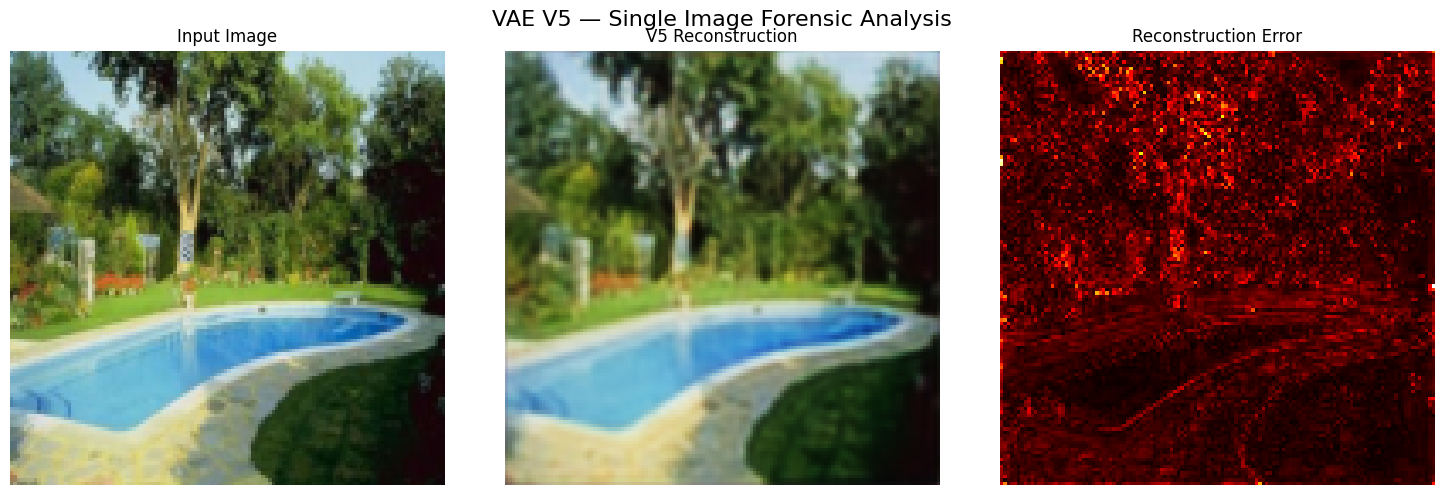

VAE V5 SINGLE IMAGE FORENSIC TEST
Image: /content/AI-Digital-Evidence-Intelligence-Platform/data/raw/CASIA2/CASIA2/Tp/Tp_D_NRN_S_N_sec00015_sec00097_11695.jpg
MSE : 0.001380
SSIM: 0.898242
SSIM error: 0.101758


In [38]:
# ============================================================
# VAE V5 — SINGLE IMAGE FORENSIC SAMPLE TEST
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms


# ------------------------------------------------------------
# SELECT A SAMPLE IMAGE
# ------------------------------------------------------------
# Change this path to any CASIA image you want to test.

SAMPLE_IMAGE_PATH = all_test_paths[0]


# ------------------------------------------------------------
# Load image
# ------------------------------------------------------------

image = Image.open(
    SAMPLE_IMAGE_PATH
).convert("RGB")


# ------------------------------------------------------------
# Same preprocessing used during training
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


image_tensor = transform(
    image
).unsqueeze(0).to(DEVICE)


# ------------------------------------------------------------
# V5 reconstruction
# ------------------------------------------------------------

vae_v5_forensic.eval()

with torch.no_grad():

    mu, logvar, e1, e2, e3, e4 = (
        vae_v5_forensic.encode(
            image_tensor
        )
    )

    reconstruction = (
        vae_v5_forensic.decode(
            mu,
            e1,
            e2,
            e3,
            e4
        )
    )


# ------------------------------------------------------------
# Reconstruction MSE
# ------------------------------------------------------------

mse = (
    (reconstruction - image_tensor) ** 2
).mean().item()


# ------------------------------------------------------------
# SSIM
# ------------------------------------------------------------

from skimage.metrics import structural_similarity

original_np = (
    image_tensor[0]
    .cpu()
    .permute(1, 2, 0)
    .numpy()
)

reconstruction_np = (
    reconstruction[0]
    .cpu()
    .permute(1, 2, 0)
    .numpy()
)

ssim = structural_similarity(
    original_np,
    reconstruction_np,
    channel_axis=2,
    data_range=1.0
)


# ------------------------------------------------------------
# Difference map
# ------------------------------------------------------------

difference = np.abs(
    original_np - reconstruction_np
)

error_map = difference.mean(
    axis=2
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)


axes[0].imshow(
    original_np
)

axes[0].set_title(
    "Input Image"
)

axes[0].axis("off")


axes[1].imshow(
    reconstruction_np
)

axes[1].set_title(
    "V5 Reconstruction"
)

axes[1].axis("off")


axes[2].imshow(
    error_map,
    cmap="hot"
)

axes[2].set_title(
    "Reconstruction Error"
)

axes[2].axis("off")


plt.suptitle(
    "VAE V5 — Single Image Forensic Analysis",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# RESULT
# ------------------------------------------------------------

print("=" * 75)
print("VAE V5 SINGLE IMAGE FORENSIC TEST")
print("=" * 75)

print(
    "Image:",
    SAMPLE_IMAGE_PATH
)

print(
    "MSE :",
    f"{mse:.6f}"
)

print(
    "SSIM:",
    f"{ssim:.6f}"
)

print(
    "SSIM error:",
    f"{1.0 - ssim:.6f}"
)

print("=" * 75)

# VAE V5 — 10-Sample Forensic Classification Demonstration

A small balanced demonstration is performed using:

- 5 authentic images
- 5 tampered images

A classification threshold is calculated from the **95th percentile of authentic validation MSE**.

The threshold is:

0.006039

Decision rule:

MSE > threshold
→ Suspicious

MSE ≤ threshold
→ Likely Authentic

This demonstration is intended to make model behavior easy to understand during project presentation.

It is not a replacement for the full test-set ROC-AUC evaluation.

V5 FORENSIC CLASSIFICATION TEST
Authentic validation samples : 1124
95th percentile MSE threshold: 0.006039

10-SAMPLE CLASSIFICATION RESULTS


,Sample,Ground Truth,V5 MSE,V5 Prediction,Correct
0,1,Authentic,0.001440,Likely Authentic,✓
1,2,Authentic,0.000631,Likely Authentic,✓
2,3,Authentic,0.002849,Likely Authentic,✓
3,4,Authentic,0.000719,Likely Authentic,✓
4,5,Authentic,0.000719,Likely Authentic,✓
5,6,Tampered,0.001873,Likely Authentic,✗
6,7,Tampered,0.008237,Suspicious,✓
7,8,Tampered,0.002002,Likely Authentic,✗
8,9,Tampered,0.001187,Likely Authentic,✗
9,10,Tampered,0.004728,Likely Authentic,✗



SAMPLE TEST SUMMARY
Total samples : 10
Correct       : 6
Incorrect     : 4
Sample accuracy: 60.0%

Classification threshold: 0.006039


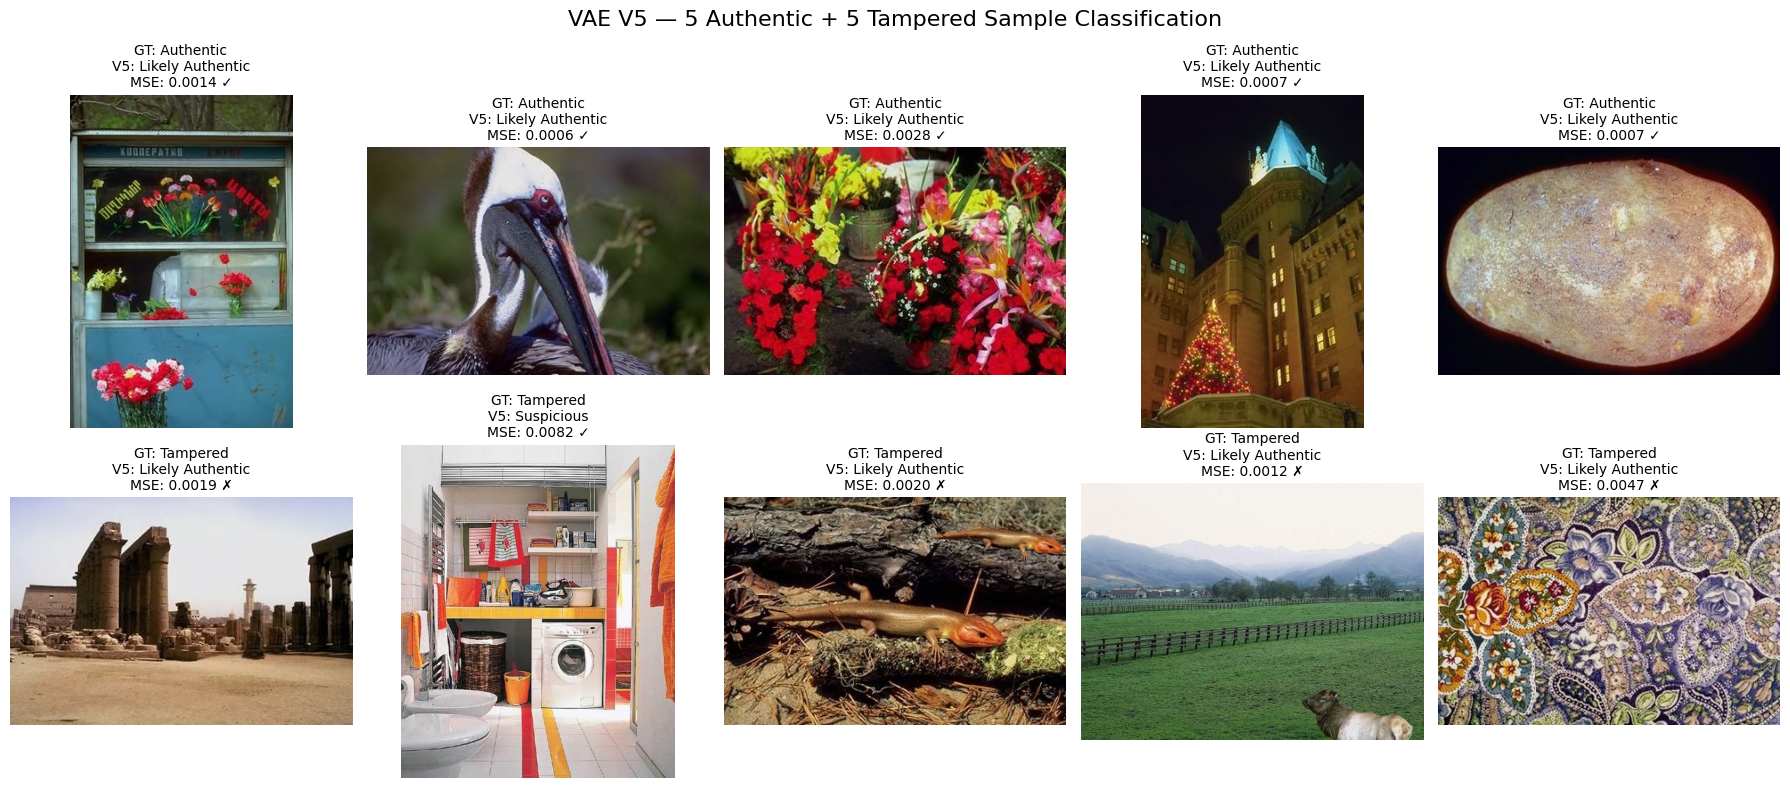

In [40]:
# ============================================================
# VAE V5 — 10-SAMPLE FORENSIC CLASSIFICATION TEST
# 5 AUTHENTIC + 5 TAMPERED
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image


# ============================================================
# STEP 1 — CREATE DATA-DRIVEN THRESHOLD
# ============================================================
# Use ONLY authentic validation reconstruction errors.
# 95th percentile = images above this are considered suspicious.

authentic_val_errors = all_mse_val[
    all_labels_val == 0
]

V5_FORENSIC_THRESHOLD = np.percentile(
    authentic_val_errors,
    95
)

print("=" * 80)
print("V5 FORENSIC CLASSIFICATION TEST")
print("=" * 80)

print(
    "Authentic validation samples :",
    len(authentic_val_errors)
)

print(
    "95th percentile MSE threshold:",
    f"{V5_FORENSIC_THRESHOLD:.6f}"
)


# ============================================================
# STEP 2 — SELECT 5 AUTHENTIC + 5 TAMPERED
# ============================================================

rng = np.random.default_rng(42)

auth_indices = np.where(
    all_test_labels == 0
)[0]

tampered_indices = np.where(
    all_test_labels == 1
)[0]


selected_auth_indices = rng.choice(
    auth_indices,
    size=5,
    replace=False
)

selected_tampered_indices = rng.choice(
    tampered_indices,
    size=5,
    replace=False
)


selected_indices = np.concatenate([
    selected_auth_indices,
    selected_tampered_indices
])


# ============================================================
# STEP 3 — RUN V5 ON 10 SAMPLES
# ============================================================

results = []

vae_v5_forensic.eval()


for sample_number, idx in enumerate(
    selected_indices,
    start=1
):

    image_path = all_test_paths[idx]

    true_label = int(
        all_test_labels[idx]
    )

    true_name = (
        "Authentic"
        if true_label == 0
        else "Tampered"
    )


    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    image = Image.open(
        image_path
    ).convert("RGB")


    image_tensor = transform(
        image
    ).unsqueeze(0).to(DEVICE)


    # --------------------------------------------------------
    # V5 reconstruction
    # --------------------------------------------------------

    with torch.no_grad():

        mu, logvar, e1, e2, e3, e4 = (
            vae_v5_forensic.encode(
                image_tensor
            )
        )

        reconstruction = (
            vae_v5_forensic.decode(
                mu,
                e1,
                e2,
                e3,
                e4
            )
        )


    # --------------------------------------------------------
    # MSE anomaly score
    # --------------------------------------------------------

    mse = (
        (reconstruction - image_tensor) ** 2
    ).mean().item()


    # --------------------------------------------------------
    # V5 classification
    # --------------------------------------------------------

    prediction = (
        "Suspicious"
        if mse > V5_FORENSIC_THRESHOLD
        else "Likely Authentic"
    )


    # --------------------------------------------------------
    # Correct / incorrect
    # --------------------------------------------------------

    if true_label == 0:

        correct = (
            prediction == "Likely Authentic"
        )

    else:

        correct = (
            prediction == "Suspicious"
        )


    results.append({
        "Sample": sample_number,
        "Ground Truth": true_name,
        "V5 MSE": mse,
        "Threshold": V5_FORENSIC_THRESHOLD,
        "V5 Prediction": prediction,
        "Correct": "✓" if correct else "✗",
        "Path": image_path
    })


# ============================================================
# STEP 4 — RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)


print()
print("=" * 80)
print("10-SAMPLE CLASSIFICATION RESULTS")
print("=" * 80)

display(
    results_df[
        [
            "Sample",
            "Ground Truth",
            "V5 MSE",
            "V5 Prediction",
            "Correct"
        ]
    ]
)


# ============================================================
# STEP 5 — SUMMARY
# ============================================================

correct_count = (
    results_df["Correct"] == "✓"
).sum()

accuracy_10 = (
    correct_count / len(results_df)
)


print()
print("=" * 80)
print("SAMPLE TEST SUMMARY")
print("=" * 80)

print(
    "Total samples :",
    len(results_df)
)

print(
    "Correct       :",
    correct_count
)

print(
    "Incorrect     :",
    len(results_df) - correct_count
)

print(
    "Sample accuracy:",
    f"{accuracy_10 * 100:.1f}%"
)

print()
print(
    "Classification threshold:",
    f"{V5_FORENSIC_THRESHOLD:.6f}"
)

print("=" * 80)


# ============================================================
# STEP 6 — VISUALIZE ALL 10
# ============================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8)
)

for ax, result in zip(
    axes.flat,
    results
):

    image = Image.open(
        result["Path"]
    ).convert("RGB")

    ax.imshow(image)

    ax.set_title(
        f"GT: {result['Ground Truth']}\n"
        f"V5: {result['V5 Prediction']}\n"
        f"MSE: {result['V5 MSE']:.4f} "
        f"{result['Correct']}",
        fontsize=10
    )

    ax.axis("off")


plt.suptitle(
    "VAE V5 — 5 Authentic + 5 Tampered Sample Classification",
    fontsize=16
)

plt.tight_layout()
plt.show()

# VAE V5 — Experimental Results

## Reconstruction V5

Best validation result:

- Best epoch: 9
- Validation MSE: 0.002862
- Validation PSNR: 25.43 dB

## Authentic-Only Forensic V5

Training:

- Authentic training images: 5,243
- Tampered training images: 0

Validation:

- Authentic validation images: 1,124
- Tampered validation images: 0

Best checkpoint:

- Best epoch: 18
- Validation MSE: 0.002313
- Validation PSNR: 26.36 dB

## Final Test

Test set:

- Authentic: 1,124
- Tampered: 769
- Total: 1,893

Test ROC-AUC:

- MSE: 0.5518
- SSIM-error: 0.5576
- MSE + SSIM: 0.5570

The earlier authentic-only MSE-based forensic evaluation produced a ROC-AUC of 0.6008 and is retained as the stronger V5 reconstruction-error baseline.

# VAE V5 — Final Conclusion

VAE V5 successfully improved reconstruction quality compared with the earlier VAE experiments.

The authentic-only forensic training strategy also produced a measurable improvement in reconstruction-based forensic behavior.

The strongest observed V5 forensic baseline achieved:

**ROC-AUC = 0.6008**

However, the reconstruction-error distributions still showed substantial overlap between authentic and tampered images.

The MSE + SSIM experiment did not provide a meaningful improvement, with a final test ROC-AUC of **0.5570**.

Therefore, V5 is best positioned as a:

### Forensic Reconstruction and Anomaly-Analysis Module

rather than a standalone tampering detector.

In the complete AI Digital Evidence Intelligence Platform, V5 can provide:

- Reconstruction evidence
- Difference/error maps
- Image-level anomaly measurements
- Supporting forensic indicators

A separate supervised image classifier can provide the primary real/fake classification signal.

The next stage is therefore to integrate the V5 forensic evidence with the project's primary image-classification model through a controlled evidence-fusion pipeline.

**VAE V5 experiment completed.**
